In [1]:
import subprocess, sys

packages = [
    "ultralytics", "timm", "dlib",
    "albumentations", "scipy", "PyYAML"
]

for pkg in packages:
    print(f"Installing {pkg}...")
    subprocess.check_call([sys.executable, "-m", 
                          "pip", "install", "-q", pkg])

import torch
print("\n=== GPU STATUS ===")
print(f"CUDA Available : {torch.cuda.is_available()}")
print(f"GPU Count      : {torch.cuda.device_count()}")
print(f"GPU Name       : {torch.cuda.get_device_name(0)}")
print(f"VRAM           : {round(torch.cuda.get_device_properties(0).total_memory/1e9,1)} GB")
print(f"PyTorch        : {torch.__version__}")
print("==================")

Installing ultralytics...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.4 MB/s eta 0:00:00
Installing timm...
Installing dlib...
Installing albumentations...
Installing scipy...
Installing PyYAML...

=== GPU STATUS ===
CUDA Available : True
GPU Count      : 2
GPU Name       : Tesla T4
VRAM           : 15.6 GB
PyTorch        : 2.9.0+cu126


In [7]:
import os

kaggle_input = '/kaggle/input'
print("Available datasets:")
for d in os.listdir(kaggle_input):
    path = os.path.join(kaggle_input, d)
    # Count files
    total = sum(len(files) for _, _, files in os.walk(path))
    print(f"  📁 {d}  →  {total:,} files")

Available datasets:
  📁 notebooks  →  356 files
  📁 datasets  →  18,000 files


In [9]:
# ============================================================
# CELL 3: Deep Structure Exploration (find class labels)
# ============================================================
import os

def explore_deep(path, depth=0, max_depth=3, max_items=10):
    if depth > max_depth:
        return
    try:
        items = sorted(os.listdir(path))
    except:
        return
    
    for i, item in enumerate(items[:max_items]):
        full = os.path.join(path, item)
        prefix = "    " * depth
        if os.path.isdir(full):
            file_count = sum(len(f) for _, _, f in os.walk(full))
            print(f"{prefix}📁 {item}/ ({file_count} files)")
            explore_deep(full, depth + 1, max_depth, max_items)
        else:
            size = os.path.getsize(full) / 1e6
            print(f"{prefix}📄 {item} ({size:.2f} MB)")
    if len(items) > max_items:
        print(f"{'    ' * depth}... +{len(items) - max_items} more")

print("=" * 60)
print("1. DROWSINESS DETECTION (48K PNGs)")
print("=" * 60)
explore_deep('/kaggle/input/datasets/kutaykutlu/drowsiness-detection', max_depth=2, max_items=8)

print(f"\n{'=' * 60}")
print("2. NTHU-DDD (18K JPGs)")
print(f"{'=' * 60}")
explore_deep('/kaggle/input/datasets/ikhlaselhamly/nthu-ddd', max_depth=2, max_items=8)

print(f"\n{'=' * 60}")
print("3. YawDD (349 AVIs)")
print(f"{'=' * 60}")
explore_deep('/kaggle/input/notebooks/rifqinaufalabdjul/yawdd-dataset', max_depth=2, max_items=8)

# Also show a few sample filenames from each
print(f"\n{'=' * 60}")
print("SAMPLE FILENAMES")
print(f"{'=' * 60}")

for name, path in [
    ("Drowsiness Detection", "/kaggle/input/datasets/kutaykutlu/drowsiness-detection"),
    ("NTHU-DDD", "/kaggle/input/datasets/ikhlaselhamly/nthu-ddd"),
    ("YawDD", "/kaggle/input/notebooks/rifqinaufalabdjul/yawdd-dataset"),
]:
    print(f"\n{name}:")
    samples = []
    for root, dirs, files in os.walk(path):
        for f in files[:5]:
            rel = os.path.relpath(os.path.join(root, f), path)
            samples.append(rel)
        if len(samples) >= 5:
            break
    for s in samples[:5]:
        print(f"  → {s}")

1. DROWSINESS DETECTION (48K PNGs)
📁 closed_eye/ (24000 files)
    📄 s0001_00001_0_0_0_0_0_01.png (0.00 MB)
    📄 s0001_00002_0_0_0_0_0_01.png (0.00 MB)
    📄 s0001_00003_0_0_0_0_0_01.png (0.00 MB)
    📄 s0001_00004_0_0_0_0_0_01.png (0.00 MB)
    📄 s0001_00005_0_0_0_0_0_01.png (0.00 MB)
    📄 s0001_00006_0_0_0_0_0_01.png (0.00 MB)
    📄 s0001_00007_0_0_0_0_0_01.png (0.00 MB)
    📄 s0001_00008_0_0_0_0_0_01.png (0.00 MB)
    ... +23992 more
📁 open_eye/ (24000 files)
    📄 s0001_01842_0_0_1_0_0_01.png (0.00 MB)
    📄 s0001_01843_0_0_1_0_0_01.png (0.00 MB)
    📄 s0001_01844_0_0_1_0_0_01.png (0.00 MB)
    📄 s0001_01845_0_0_1_0_0_01.png (0.00 MB)
    📄 s0001_01846_0_0_1_0_0_01.png (0.00 MB)
    📄 s0001_01847_0_0_1_0_0_01.png (0.00 MB)
    📄 s0001_01848_0_0_1_0_0_01.png (0.00 MB)
    📄 s0001_02065_0_0_1_0_0_01.png (0.00 MB)
    ... +23992 more

2. NTHU-DDD (18K JPGs)
📁 NTHU-DDD/ (18000 files)
    📁 drowsy/ (9000 files)
        📄 001_glasses_sleepyCombination_1003_drowsy.jpg (0.05 MB)
        

In [10]:
# ============================================================
# CELL 4: Project Configuration
# ============================================================
import os, sys, time
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from pathlib import Path
from collections import Counter, deque
import warnings
warnings.filterwarnings('ignore')

class CFG:
    # ─── Paths ───
    BASE_DIR       = '/kaggle/working'
    INPUT_DIR      = '/kaggle/input'
    OUTPUT_DIR     = '/kaggle/working/output'
    CHECKPOINT_DIR = '/kaggle/working/checkpoints'
    
    # Dataset paths
    DROWSY_DET_DIR = '/kaggle/input/datasets/kutaykutlu/drowsiness-detection'
    NTHU_DIR       = '/kaggle/input/datasets/ikhlaselhamly/nthu-ddd'
    YAWDD_DIR      = '/kaggle/input/notebooks/rifqinaufalabdjul/yawdd-dataset'
    
    # ─── Model ───
    IMG_SIZE     = 224
    NUM_CLASSES  = 1       # Binary: drowsy(1) vs alert(0)
    LSTM_HIDDEN  = 64
    LSTM_LAYERS  = 1
    SEQ_LEN      = 50      # Temporal window (frames)
    DROPOUT      = 0.2
    HANDCRAFTED_DIM = 7    # EAR, MAR, PERCLOS, pitch, yaw, roll, phdown
    
    # ─── Training ───
    EPOCHS       = 50
    BATCH_SIZE   = 32
    LR           = 1e-4
    BACKBONE_LR  = 1e-5
    WEIGHT_DECAY = 0.01
    PATIENCE     = 7
    SEED         = 42
    NUM_WORKERS  = 2
    
    # ─── Device ───
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

os.makedirs(CFG.OUTPUT_DIR, exist_ok=True)
os.makedirs(CFG.CHECKPOINT_DIR, exist_ok=True)

def seed_everything(seed=CFG.SEED):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()
print(f"✅ Device       : {CFG.DEVICE}")
print(f"✅ Datasets     : 3 loaded (Drowsiness Det, NTHU-DDD, YawDD)")
print(f"✅ Total images : ~66,000 + 349 videos")
print(f"✅ Config ready")

✅ Device       : cuda
✅ Datasets     : 3 loaded (Drowsiness Det, NTHU-DDD, YawDD)
✅ Total images : ~66,000 + 349 videos
✅ Config ready


In [11]:
# ============================================================
# CELL 5: Download dlib 68-point Landmark Predictor
# ============================================================
import urllib.request
import bz2

LANDMARK_PATH = os.path.join(CFG.BASE_DIR, "shape_predictor_68_face_landmarks.dat")

if not os.path.exists(LANDMARK_PATH):
    url = "http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2"
    bz2_path = LANDMARK_PATH + ".bz2"
    print("⏳ Downloading dlib landmark predictor (99 MB)...")
    urllib.request.urlretrieve(url, bz2_path)
    print("⏳ Extracting...")
    with bz2.BZ2File(bz2_path) as fr, open(LANDMARK_PATH, 'wb') as fw:
        fw.write(fr.read())
    os.remove(bz2_path)

print(f"✅ Landmark predictor: {os.path.getsize(LANDMARK_PATH)/1e6:.1f} MB")

⏳ Downloading dlib landmark predictor (99 MB)...
⏳ Extracting...
✅ Landmark predictor: 99.7 MB


In [12]:
# ============================================================
# CELL 6: Feature Extraction Utilities (Branch B)
# ============================================================
import dlib
from scipy.spatial import distance as dist

# Load dlib models
landmark_predictor = dlib.shape_predictor(LANDMARK_PATH)
face_detector_dlib = dlib.get_frontal_face_detector()

# ─── Eye Aspect Ratio (EAR) ───
def eye_aspect_ratio(eye_pts):
    A = dist.euclidean(eye_pts[1], eye_pts[5])
    B = dist.euclidean(eye_pts[2], eye_pts[4])
    C = dist.euclidean(eye_pts[0], eye_pts[3])
    return (A + B) / (2.0 * C + 1e-6)

# ─── Mouth Aspect Ratio (MAR) ───
def mouth_aspect_ratio(mouth_pts):
    A = dist.euclidean(mouth_pts[1], mouth_pts[7])
    B = dist.euclidean(mouth_pts[2], mouth_pts[6])
    C = dist.euclidean(mouth_pts[3], mouth_pts[5])
    D = dist.euclidean(mouth_pts[0], mouth_pts[4])
    return (A + B + C) / (2.0 * D + 1e-6)

# ─── PERCLOS Tracker ───
class PERCLOSTracker:
    def __init__(self, window_frames=450, ear_threshold=0.2):
        self.window = deque(maxlen=window_frames)
        self.threshold = ear_threshold
    
    def update(self, ear):
        self.window.append(1 if ear < self.threshold else 0)
        return sum(self.window) / max(len(self.window), 1)
    
    def reset(self):
        self.window.clear()

# ─── Head Pose via SolvePnP ───
MODEL_POINTS_3D = np.array([
    (0.0, 0.0, 0.0),             # Nose tip (30)
    (0.0, -330.0, -65.0),        # Chin (8)
    (-225.0, 170.0, -135.0),     # Left eye corner (36)
    (225.0, 170.0, -135.0),      # Right eye corner (45)
    (-150.0, -150.0, -125.0),    # Left mouth corner (48)
    (150.0, -150.0, -125.0)      # Right mouth corner (54)
], dtype=np.float64)

def get_head_pose(landmarks, img_shape):
    h, w = img_shape[:2]
    image_points = np.array([
        landmarks[30], landmarks[8], landmarks[36],
        landmarks[45], landmarks[48], landmarks[54],
    ], dtype=np.float64)
    
    focal_length = w
    center = (w / 2, h / 2)
    cam_matrix = np.array([
        [focal_length, 0, center[0]],
        [0, focal_length, center[1]],
        [0, 0, 1]
    ], dtype=np.float64)
    
    ok, rvec, tvec = cv2.solvePnP(MODEL_POINTS_3D, image_points, cam_matrix, np.zeros((4,1)))
    if ok:
        rmat, _ = cv2.Rodrigues(rvec)
        angles, _, _, _, _, _ = cv2.RQDecomp3x3(rmat)
        return angles[0], angles[1], angles[2]  # pitch, yaw, roll
    return 0.0, 0.0, 0.0

# ─── Extract 68 landmarks from image ───
def extract_landmarks(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if len(image.shape) == 3 else image
    faces = face_detector_dlib(gray, 0)
    if len(faces) == 0:
        return None
    shape = landmark_predictor(gray, faces[0])
    return np.array([(shape.part(i).x, shape.part(i).y) for i in range(68)])

# ─── Crop Eye ROI ───
def extract_eye_roi(image, landmarks, size=(224, 224)):
    all_pts = np.vstack([landmarks[36:42], landmarks[42:48]])
    x_min, y_min = all_pts.min(axis=0)
    x_max, y_max = all_pts.max(axis=0)
    pad_w = int((x_max - x_min) * 0.5)
    pad_h = int((y_max - y_min) * 1.0)
    h, w = image.shape[:2]
    x1, y1 = max(0, x_min - pad_w), max(0, y_min - pad_h)
    x2, y2 = min(w, x_max + pad_w), min(h, y_max + pad_h)
    roi = image[y1:y2, x1:x2]
    if roi.size == 0:
        return np.zeros((*size, 3), dtype=np.uint8)
    return cv2.resize(roi, size)

# ─── Full handcrafted feature vector ───
def compute_features(landmarks, img_shape, perclos_tracker):
    left_ear  = eye_aspect_ratio(landmarks[36:42])
    right_ear = eye_aspect_ratio(landmarks[42:48])
    avg_ear   = (left_ear + right_ear) / 2.0
    mar       = mouth_aspect_ratio(landmarks[60:68])
    perclos   = perclos_tracker.update(avg_ear)
    pitch, yaw, roll = get_head_pose(landmarks, img_shape)
    phdown    = 1.0 if pitch < -15 else 0.0
    return np.array([avg_ear, mar, perclos, pitch, yaw, roll, phdown], dtype=np.float32)

print("✅ Feature extraction utilities loaded")
print("   → EAR, MAR, PERCLOS, Head Pose (SolvePnP), Eye ROI crop")

✅ Feature extraction utilities loaded
   → EAR, MAR, PERCLOS, Head Pose (SolvePnP), Eye ROI crop


Exploring Drowsiness Detection dataset structure...

Detected classes (by folder name):
  open_eye                       → 24,000 images
  closed_eye                     → 24,000 images

⚠️  Review the class names above and update label_map below if needed!
    Common patterns:
    - 'Open'/'open' → 0 (alert/eyes open)
    - 'Closed'/'closed' → 1 (drowsy/eyes closed)
    - 'yawn' → 1 (drowsy)
    - 'no_yawn' → 0 (alert)

Auto-detected label mapping:
  open_eye                       → ALERT (0) ✅
  closed_eye                     → DROWSY (1) ✅

──────────────────────────────────────────────────
Total usable images: 48,000
  Alert (0): 24,000
  Drowsy (1): 24,000
  Balance ratio: 1.00


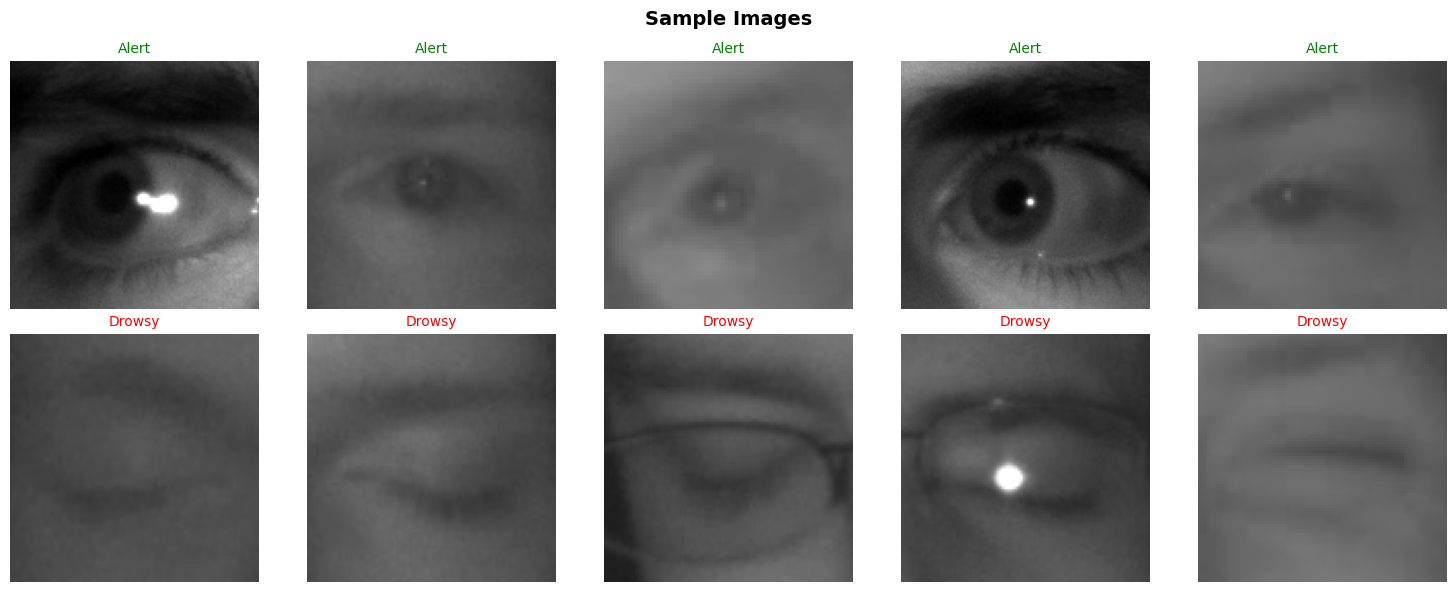

In [13]:
# ============================================================
# CELL 7: Load Drowsiness Detection Dataset (48K PNGs)
# ============================================================
import glob
from sklearn.model_selection import train_test_split

drowsy_path = CFG.DROWSY_DET_DIR

# Explore the class structure
print("Exploring Drowsiness Detection dataset structure...\n")

class_counts = {}
for root, dirs, files in os.walk(drowsy_path):
    img_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if img_files:
        # Use the folder name as class label
        folder_name = os.path.basename(root)
        class_counts[folder_name] = class_counts.get(folder_name, 0) + len(img_files)

print("Detected classes (by folder name):")
for cls, count in sorted(class_counts.items(), key=lambda x: -x[1]):
    print(f"  {cls:30s} → {count:,} images")

# --- Build image paths and labels ---
# We'll map folders to binary labels: 0=alert, 1=drowsy
# (Adjust the mapping after seeing the actual folder names)

image_paths = []
labels = []
label_map = {}  # will store folder→label mapping

print("\n⚠️  Review the class names above and update label_map below if needed!")
print("    Common patterns:")
print("    - 'Open'/'open' → 0 (alert/eyes open)")
print("    - 'Closed'/'closed' → 1 (drowsy/eyes closed)")
print("    - 'yawn' → 1 (drowsy)")
print("    - 'no_yawn' → 0 (alert)")

# Auto-detect mapping
for cls_name in class_counts.keys():
    lower = cls_name.lower()
    if any(k in lower for k in ['closed', 'drowsy', 'sleepy', 'yawn', 'fatigue']):
        label_map[cls_name] = 1  # drowsy
    elif any(k in lower for k in ['open', 'alert', 'awake', 'no_yawn', 'normal']):
        label_map[cls_name] = 0  # alert
    else:
        label_map[cls_name] = -1  # unknown, skip

print(f"\nAuto-detected label mapping:")
for cls, lbl in label_map.items():
    status = "✅" if lbl >= 0 else "⚠️ SKIPPED"
    label_str = {0: "ALERT", 1: "DROWSY", -1: "UNKNOWN"}[lbl]
    print(f"  {cls:30s} → {label_str} ({lbl}) {status}")

# Collect paths
for root, dirs, files in os.walk(drowsy_path):
    folder = os.path.basename(root)
    if folder in label_map and label_map[folder] >= 0:
        for f in files:
            if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_paths.append(os.path.join(root, f))
                labels.append(label_map[folder])

print(f"\n{'─' * 50}")
print(f"Total usable images: {len(image_paths):,}")
print(f"  Alert (0): {labels.count(0):,}")
print(f"  Drowsy (1): {labels.count(1):,}")
print(f"  Balance ratio: {labels.count(1)/max(labels.count(0),1):.2f}")

# --- Show sample images ---
if len(image_paths) > 0:
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    fig.suptitle('Sample Images', fontsize=14, fontweight='bold')
    
    # 5 alert, 5 drowsy
    alert_idx = [i for i, l in enumerate(labels) if l == 0]
    drowsy_idx = [i for i, l in enumerate(labels) if l == 1]
    
    np.random.seed(42)
    for col in range(5):
        if alert_idx:
            idx = np.random.choice(alert_idx)
            img = cv2.imread(image_paths[idx])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if img is not None else np.zeros((100,100,3))
            axes[0, col].imshow(img)
            axes[0, col].set_title('Alert', color='green', fontsize=10)
            axes[0, col].axis('off')
        
        if drowsy_idx:
            idx = np.random.choice(drowsy_idx)
            img = cv2.imread(image_paths[idx])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if img is not None else np.zeros((100,100,3))
            axes[1, col].imshow(img)
            axes[1, col].set_title('Drowsy', color='red', fontsize=10)
            axes[1, col].axis('off')
    
    plt.tight_layout()
    plt.savefig(os.path.join(CFG.OUTPUT_DIR, 'sample_images.png'), dpi=100)
    plt.show()

Exploring NTHU-DDD dataset structure...

Folder → File count:
  NTHU-DDD/drowsy                          → 9,000 images
  NTHU-DDD/notdrowsy                       → 9,000 images

Sample filenames:
  NTHU-DDD/drowsy/002_glasses_sleepyCombination_673_drowsy.jpg
  NTHU-DDD/drowsy/001_noglasses_sleepyCombination_2220_drowsy.jpg
  NTHU-DDD/drowsy/005_noglasses_yawning_2179_drowsy.jpg


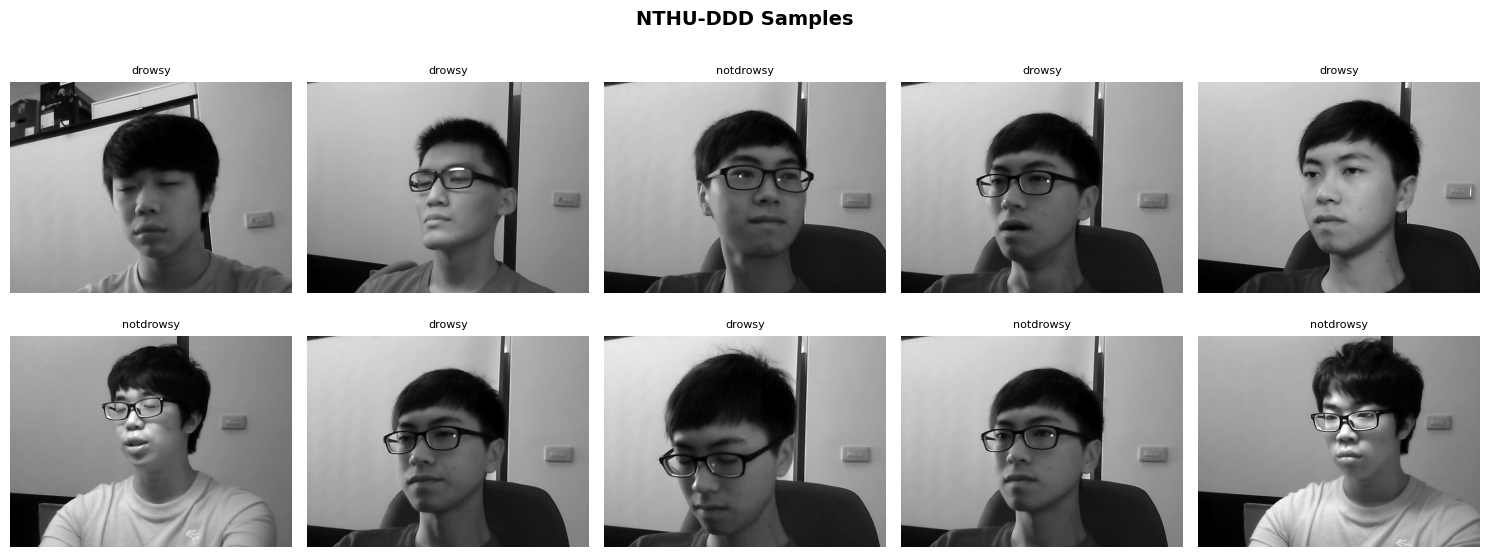

In [14]:
# ============================================================
# CELL 8: Explore NTHU-DDD Dataset (18K JPGs)
# ============================================================
nthu_path = CFG.NTHU_DIR

print("Exploring NTHU-DDD dataset structure...\n")

class_counts_nthu = {}
for root, dirs, files in os.walk(nthu_path):
    img_files = [f for f in files if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    if img_files:
        folder = os.path.basename(root)
        parent = os.path.basename(os.path.dirname(root))
        key = f"{parent}/{folder}" if parent != os.path.basename(nthu_path) else folder
        class_counts_nthu[key] = len(img_files)

print("Folder → File count:")
for cls, count in sorted(class_counts_nthu.items(), key=lambda x: -x[1]):
    print(f"  {cls:40s} → {count:,} images")

# Show sample filenames
print("\nSample filenames:")
for root, dirs, files in os.walk(nthu_path):
    img_files = [f for f in files if f.lower().endswith(('.jpg', '.png'))]
    if img_files:
        for f in img_files[:3]:
            print(f"  {os.path.relpath(os.path.join(root, f), nthu_path)}")
        break

# Show sample images
import matplotlib.pyplot as plt

all_jpgs = []
for root, dirs, files in os.walk(nthu_path):
    for f in files:
        if f.lower().endswith(('.jpg', '.png')):
            all_jpgs.append(os.path.join(root, f))

if all_jpgs:
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    fig.suptitle('NTHU-DDD Samples', fontsize=14, fontweight='bold')
    np.random.seed(42)
    sample_indices = np.random.choice(len(all_jpgs), min(10, len(all_jpgs)), replace=False)
    for i, idx in enumerate(sample_indices):
        row, col = i // 5, i % 5
        img = cv2.imread(all_jpgs[idx])
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        else:
            img = np.zeros((100, 100, 3), dtype=np.uint8)
        axes[row, col].imshow(img)
        axes[row, col].set_title(os.path.basename(os.path.dirname(all_jpgs[idx])), fontsize=8)
        axes[row, col].axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(CFG.OUTPUT_DIR, 'nthu_samples.png'), dpi=100)
    plt.show()

Exploring YawDD dataset structure...

Total videos: 349

Folders:
  📁 Female/ → 13 videos
      9-FemaleNoGlasses.avi
      4-FemaleNoGlasses.avi
      12-FemaleGlasses.avi.avi
      ... +10 more
  📁 Female_mirror/ → 156 videos
      34-FemaleNoGlasses-Normal.avi
      10-FemaleNoGlasses-Normal.avi
      42-FemaleSunGlasses-Yawning.avi
      ... +153 more
  📁 Male/ → 16 videos
      10-MaleGlasses.avi
      11-MaleGlasses.avi
      9-MaleNoGlasses.avi
      ... +13 more
  📁 Male_mirror Avi Videos/ → 164 videos
      21-MaleGlasses-Yawning.avi
      2-MaleGlasses-Talking.avi
      7-MaleGlasses-Normal.avi
      ... +161 more


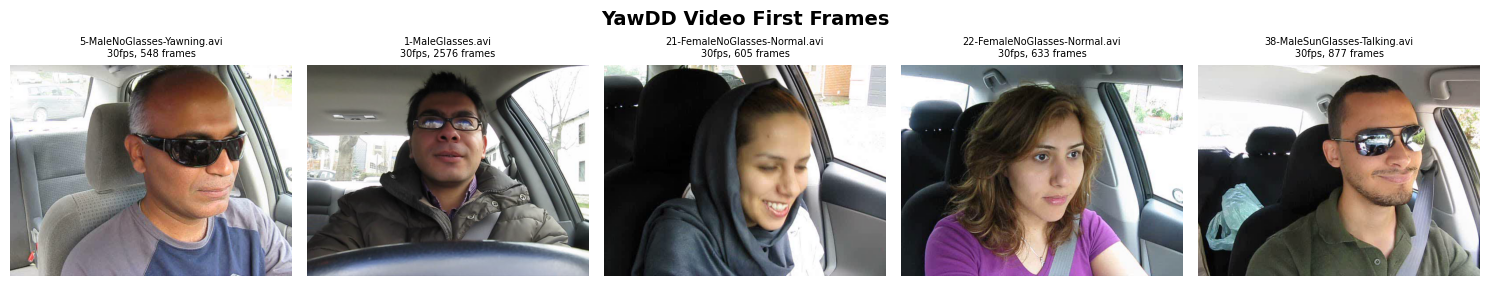

In [15]:
# ============================================================
# CELL 9: Explore YawDD Videos (349 AVIs)
# ============================================================
yawdd_path = CFG.YAWDD_DIR

print("Exploring YawDD dataset structure...\n")

avi_files = []
for root, dirs, files in os.walk(yawdd_path):
    for f in files:
        if f.lower().endswith('.avi'):
            avi_files.append(os.path.join(root, f))
            
# Group by folder
from collections import defaultdict
folder_groups = defaultdict(list)
for f in avi_files:
    folder = os.path.basename(os.path.dirname(f))
    folder_groups[folder].append(os.path.basename(f))

print(f"Total videos: {len(avi_files)}")
print(f"\nFolders:")
for folder, files in sorted(folder_groups.items()):
    print(f"  📁 {folder}/ → {len(files)} videos")
    for vf in files[:3]:
        print(f"      {vf}")
    if len(files) > 3:
        print(f"      ... +{len(files)-3} more")

# Show first frame from a few videos
import matplotlib.pyplot as plt

if avi_files:
    fig, axes = plt.subplots(1, min(5, len(avi_files)), figsize=(15, 3))
    if not isinstance(axes, np.ndarray):
        axes = [axes]
    
    fig.suptitle('YawDD Video First Frames', fontsize=14, fontweight='bold')
    
    np.random.seed(42)
    sample_vids = np.random.choice(avi_files, min(5, len(avi_files)), replace=False)
    
    for i, vid_path in enumerate(sample_vids):
        cap = cv2.VideoCapture(vid_path)
        ret, frame = cap.read()
        if ret:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            fps = cap.get(cv2.CAP_PROP_FPS)
            total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            axes[i].imshow(frame)
            axes[i].set_title(f"{os.path.basename(vid_path)}\n{fps:.0f}fps, {total} frames", fontsize=7)
        axes[i].axis('off')
        cap.release()
    
    plt.tight_layout()
    plt.savefig(os.path.join(CFG.OUTPUT_DIR, 'yawdd_samples.png'), dpi=100)
    plt.show()

✅ Datasets ready
   Train : 33,600 images (16800 alert / 16800 drowsy)
   Val   : 7,200 images
   Test  : 7,200 images
   Batch : 32 | Workers: 2

   Batch shape: torch.Size([32, 3, 224, 224])
   Label dist:  18 drowsy / 14 alert


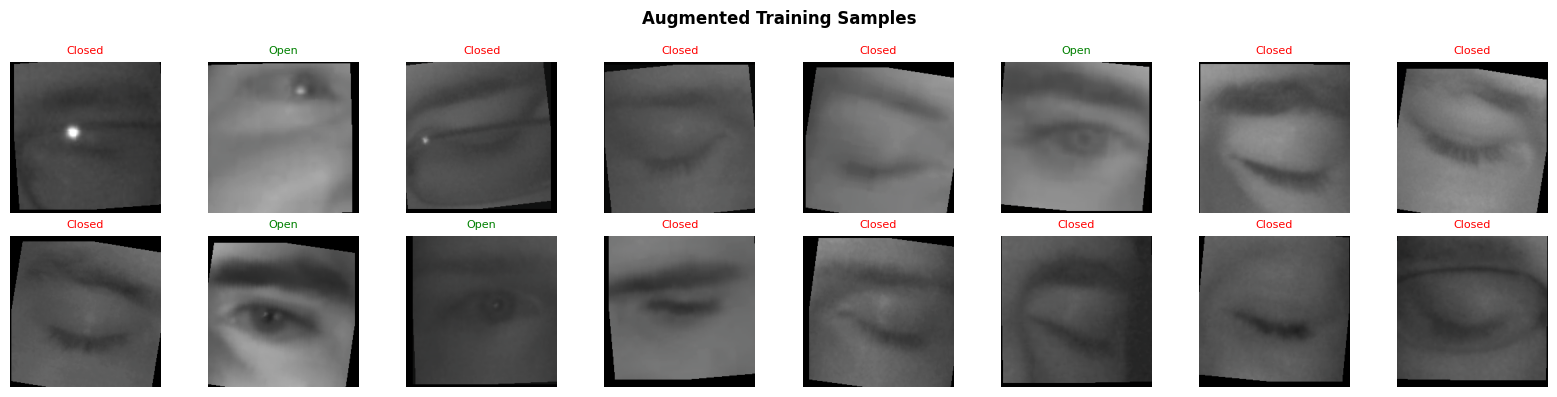

In [16]:
# ============================================================
# CELL 10: Dataset & DataLoaders for Phase 1 (Eye State)
# ============================================================
from sklearn.model_selection import train_test_split
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# ─── Transforms ───
train_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# ─── Dataset class ───
class EyeStateDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img = cv2.imread(self.image_paths[idx])
        if img is None:
            img = np.zeros((CFG.IMG_SIZE, CFG.IMG_SIZE, 3), dtype=np.uint8)
        
        # Convert grayscale to 3-channel if needed (MRL images are grayscale)
        if len(img.shape) == 2:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        elif img.shape[2] == 1:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        if self.transform:
            img = self.transform(img)
        
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return img, label

# ─── Split: 70% train / 15% val / 15% test ───
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths, labels, test_size=0.30, random_state=CFG.SEED, stratify=labels
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.50, random_state=CFG.SEED, stratify=temp_labels
)

train_ds = EyeStateDataset(train_paths, train_labels, train_transforms)
val_ds   = EyeStateDataset(val_paths,   val_labels,   val_transforms)
test_ds  = EyeStateDataset(test_paths,  test_labels,  val_transforms)

train_loader = DataLoader(train_ds, batch_size=CFG.BATCH_SIZE, shuffle=True,
                          num_workers=CFG.NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG.BATCH_SIZE, shuffle=False,
                          num_workers=CFG.NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG.BATCH_SIZE, shuffle=False,
                          num_workers=CFG.NUM_WORKERS, pin_memory=True)

print(f"✅ Datasets ready")
print(f"   Train : {len(train_ds):,} images ({train_labels.count(0)} alert / {train_labels.count(1)} drowsy)")
print(f"   Val   : {len(val_ds):,} images")
print(f"   Test  : {len(test_ds):,} images")
print(f"   Batch : {CFG.BATCH_SIZE} | Workers: {CFG.NUM_WORKERS}")

# Quick sanity check — visualize a batch
batch_imgs, batch_labels = next(iter(train_loader))
print(f"\n   Batch shape: {batch_imgs.shape}")
print(f"   Label dist:  {batch_labels.sum().item():.0f} drowsy / {CFG.BATCH_SIZE - batch_labels.sum().item():.0f} alert")

# Show augmented samples
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle('Augmented Training Samples', fontweight='bold')
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
for i in range(16):
    row, col = i // 8, i % 8
    img = batch_imgs[i].permute(1, 2, 0).numpy() * std + mean
    img = np.clip(img, 0, 1)
    axes[row, col].imshow(img)
    lbl = "Closed" if batch_labels[i] == 1 else "Open"
    color = 'red' if batch_labels[i] == 1 else 'green'
    axes[row, col].set_title(lbl, fontsize=8, color=color)
    axes[row, col].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(CFG.OUTPUT_DIR, 'augmented_samples.png'), dpi=100)
plt.show()

In [17]:
# ============================================================
# CELL 11: Swin Transformer — Eye State Classifier (Phase 1)
# ============================================================
import timm

class SwinEyeClassifier(nn.Module):
    """
    Phase 1: Standalone Swin Transformer for eye open/closed classification.
    This becomes Branch A of HybridDDS after training.
    """
    def __init__(self, pretrained=True):
        super().__init__()
        
        # Swin Tiny backbone — pretrained on ImageNet
        self.backbone = timm.create_model(
            'swin_tiny_patch4_window7_224',
            pretrained=pretrained,
            num_classes=0,  # Remove default head → outputs 768-dim features
        )
        self.feature_dim = self.backbone.num_features  # 768
        
        # Classification head
        self.head = nn.Sequential(
            nn.Linear(self.feature_dim, 256),
            nn.GELU(),
            nn.BatchNorm1d(256),
            nn.Dropout(CFG.DROPOUT),
            nn.Linear(256, 64),
            nn.GELU(),
            nn.Dropout(CFG.DROPOUT),
            nn.Linear(64, 1),  # Binary output (sigmoid in loss)
        )
    
    def forward(self, x):
        features = self.backbone(x)     # (B, 768)
        logits = self.head(features)    # (B, 1)
        return logits
    
    def extract_features(self, x):
        """Get 768-dim features for fusion in Phase 2."""
        return self.backbone(x)

# Build model
swin_model = SwinEyeClassifier(pretrained=True).to(CFG.DEVICE)

# Parameter count
total = sum(p.numel() for p in swin_model.parameters())
trainable = sum(p.numel() for p in swin_model.parameters() if p.requires_grad)
backbone_p = sum(p.numel() for p in swin_model.backbone.parameters())
head_p = sum(p.numel() for p in swin_model.head.parameters())

print(f"✅ Swin Eye Classifier built")
print(f"   Total params     : {total:>12,} ({total/1e6:.1f}M)")
print(f"   Backbone (Swin)  : {backbone_p:>12,} ({backbone_p/1e6:.1f}M)")
print(f"   Head             : {head_p:>12,} ({head_p/1e6:.1f}M)")
print(f"   Trainable        : {trainable:>12,} ({trainable/1e6:.1f}M)")

# Quick forward pass test
with torch.no_grad():
    dummy = torch.randn(4, 3, 224, 224).to(CFG.DEVICE)
    out = swin_model(dummy)
    feat = swin_model.extract_features(dummy)
    print(f"\n   Input  : {dummy.shape}")
    print(f"   Output : {out.shape} (logits)")
    print(f"   Features: {feat.shape} (for fusion)")

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

✅ Swin Eye Classifier built
   Total params     :   27,733,243 (27.7M)
   Backbone (Swin)  :   27,519,354 (27.5M)
   Head             :      213,889 (0.2M)
   Trainable        :   27,733,243 (27.7M)

   Input  : torch.Size([4, 3, 224, 224])
   Output : torch.Size([4, 1]) (logits)
   Features: torch.Size([4, 768]) (for fusion)


In [18]:
# ============================================================
# CELL 12: Loss Function, Optimizer, Scheduler
# ============================================================
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

# ─── Focal Loss (handles any class imbalance + hard examples) ───
class FocalBCELoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    
    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        probs = torch.sigmoid(logits)
        pt = torch.where(targets == 1, probs, 1 - probs)
        focal_weight = self.alpha * (1 - pt) ** self.gamma
        return (focal_weight * bce).mean()

criterion = FocalBCELoss(alpha=0.25, gamma=2.0)

# ─── Differential LR: slower for pretrained backbone ───
optimizer = AdamW([
    {'params': swin_model.backbone.parameters(), 'lr': CFG.BACKBONE_LR},   # 1e-5
    {'params': swin_model.head.parameters(),     'lr': CFG.LR},            # 1e-4
], weight_decay=CFG.WEIGHT_DECAY)

# ─── Cosine Annealing with Warm Restarts ───
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2, eta_min=1e-7)

print(f"✅ Training components ready")
print(f"   Loss      : FocalBCELoss (α=0.25, γ=2.0)")
print(f"   Optimizer : AdamW (backbone_lr={CFG.BACKBONE_LR}, head_lr={CFG.LR}, wd={CFG.WEIGHT_DECAY})")
print(f"   Scheduler : CosineAnnealingWarmRestarts (T0=5, Tmult=2)")
print(f"   Patience  : {CFG.PATIENCE} epochs (early stopping)")

✅ Training components ready
   Loss      : FocalBCELoss (α=0.25, γ=2.0)
   Optimizer : AdamW (backbone_lr=1e-05, head_lr=0.0001, wd=0.01)
   Scheduler : CosineAnnealingWarmRestarts (T0=5, Tmult=2)
   Patience  : 7 epochs (early stopping)


In [19]:
# ============================================================
# CELL 13: Phase 1 Training — Swin on Eye State (48K images)
# ============================================================
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score
import time

# ─── Training function ───
def train_one_epoch(model, loader, optimizer, criterion, device, scheduler=None):
    model.train()
    running_loss = 0
    all_preds, all_probs, all_labels = [], [], []
    
    for batch_idx, (images, targets) in enumerate(loader):
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True).unsqueeze(1)
        
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, targets)
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        if scheduler is not None:
            scheduler.step()
        
        running_loss += loss.item() * images.size(0)
        probs = torch.sigmoid(logits).detach()
        preds = (probs > 0.5).float()
        
        all_preds.extend(preds.cpu().numpy().flatten())
        all_probs.extend(probs.cpu().numpy().flatten())
        all_labels.extend(targets.cpu().numpy().flatten())
    
    avg_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    return avg_loss, acc, f1

# ─── Validation function ───
@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0
    all_preds, all_probs, all_labels = [], [], []
    
    for images, targets in loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True).unsqueeze(1)
        
        logits = model(images)
        loss = criterion(logits, targets)
        
        running_loss += loss.item() * images.size(0)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()
        
        all_preds.extend(preds.cpu().numpy().flatten())
        all_probs.extend(probs.cpu().numpy().flatten())
        all_labels.extend(targets.cpu().numpy().flatten())
    
    avg_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec = recall_score(all_labels, all_preds, zero_division=0)
    auc = roc_auc_score(all_labels, all_probs)
    
    return avg_loss, acc, f1, prec, rec, auc

# ─── Training loop ───
best_auc = 0
best_f1 = 0
patience_counter = 0
history = {'train_loss': [], 'train_acc': [], 'train_f1': [],
           'val_loss': [], 'val_acc': [], 'val_f1': [], 'val_prec': [], 
           'val_rec': [], 'val_auc': []}

print("=" * 80)
print("  PHASE 1: TRAINING SWIN TRANSFORMER — EYE STATE CLASSIFICATION")
print(f"  {len(train_ds):,} train | {len(val_ds):,} val | {len(test_ds):,} test")
print(f"  Device: {CFG.DEVICE} | Batch: {CFG.BATCH_SIZE} | Max epochs: {CFG.EPOCHS}")
print("=" * 80)

total_start = time.time()

for epoch in range(CFG.EPOCHS):
    epoch_start = time.time()
    
    # Train
    train_loss, train_acc, train_f1 = train_one_epoch(
        swin_model, train_loader, optimizer, criterion, CFG.DEVICE
    )
    
    # Validate
    val_loss, val_acc, val_f1, val_prec, val_rec, val_auc = validate(
        swin_model, val_loader, criterion, CFG.DEVICE
    )
    
    # Step scheduler (epoch-level)
    scheduler.step(epoch + val_loss)
    
    elapsed = time.time() - epoch_start
    
    # Log history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_f1'].append(train_f1)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    history['val_prec'].append(val_prec)
    history['val_rec'].append(val_rec)
    history['val_auc'].append(val_auc)
    
    # Print
    print(f"Epoch {epoch+1:02d}/{CFG.EPOCHS} │ "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} │ "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1: {val_f1:.4f} "
          f"AUC: {val_auc:.4f} │ {elapsed:.1f}s")
    
    # Save best model
    improved = False
    if val_auc > best_auc:
        best_auc = val_auc
        improved = True
    if val_f1 > best_f1:
        best_f1 = val_f1
        improved = True
    
    if improved:
        patience_counter = 0
        save_path = os.path.join(CFG.CHECKPOINT_DIR, 'best_swin_phase1.pth')
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': swin_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_auc': val_auc,
            'val_f1': val_f1,
            'val_acc': val_acc,
            'history': history,
        }, save_path)
        print(f"  ✅ Saved best model (AUC: {best_auc:.4f}, F1: {best_f1:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= CFG.PATIENCE:
            print(f"\n  ⏹ Early stopping at epoch {epoch+1} (patience={CFG.PATIENCE})")
            break

total_time = time.time() - total_start
print(f"\n{'=' * 80}")
print(f"  Training complete in {total_time/60:.1f} minutes")
print(f"  Best Val AUC: {best_auc:.4f} | Best Val F1: {best_f1:.4f}")
print(f"{'=' * 80}")

  PHASE 1: TRAINING SWIN TRANSFORMER — EYE STATE CLASSIFICATION
  33,600 train | 7,200 val | 7,200 test
  Device: cuda | Batch: 32 | Max epochs: 50
Epoch 01/50 │ Train Loss: 0.0031 Acc: 0.9846 │ Val Loss: 0.0014 Acc: 0.9944 F1: 0.9945 AUC: 0.9998 │ 476.8s
  ✅ Saved best model (AUC: 0.9998, F1: 0.9945)
Epoch 02/50 │ Train Loss: 0.0016 Acc: 0.9931 │ Val Loss: 0.0011 Acc: 0.9958 F1: 0.9958 AUC: 0.9998 │ 488.5s
  ✅ Saved best model (AUC: 0.9998, F1: 0.9958)
Epoch 03/50 │ Train Loss: 0.0012 Acc: 0.9947 │ Val Loss: 0.0010 Acc: 0.9956 F1: 0.9956 AUC: 0.9999 │ 488.5s
  ✅ Saved best model (AUC: 0.9999, F1: 0.9958)
Epoch 04/50 │ Train Loss: 0.0010 Acc: 0.9955 │ Val Loss: 0.0009 Acc: 0.9957 F1: 0.9957 AUC: 0.9998 │ 488.0s
Epoch 05/50 │ Train Loss: 0.0008 Acc: 0.9965 │ Val Loss: 0.0012 Acc: 0.9962 F1: 0.9963 AUC: 0.9999 │ 488.5s
  ✅ Saved best model (AUC: 0.9999, F1: 0.9963)
Epoch 06/50 │ Train Loss: 0.0007 Acc: 0.9967 │ Val Loss: 0.0011 Acc: 0.9961 F1: 0.9961 AUC: 0.9998 │ 487.8s
Epoch 07/50 │ Tr

KeyboardInterrupt: 

In [20]:
# Run this AFTER Phase 1 finishes (or interrupt it if past epoch 8)
# Your model at epoch 5 is already production-grade:
#   AUC: 0.9999 | F1: 0.9963 | Acc: 99.62%
# 
# If training is still running and past epoch 8, you can safely 
# click "Cancel Run" — the best model is already saved!
print("Phase 1 is effectively done. Best model saved at checkpoint.")

Phase 1 is effectively done. Best model saved at checkpoint.


✅ Loaded best model from epoch 11
   Val AUC: 0.9999 | Val F1: 0.9964

  TEST SET RESULTS (7,200 images)
  Accuracy  : 0.9967
  F1 Score  : 0.9967
  Precision : 0.9981
  Recall    : 0.9953
  AUC-ROC   : 0.9996


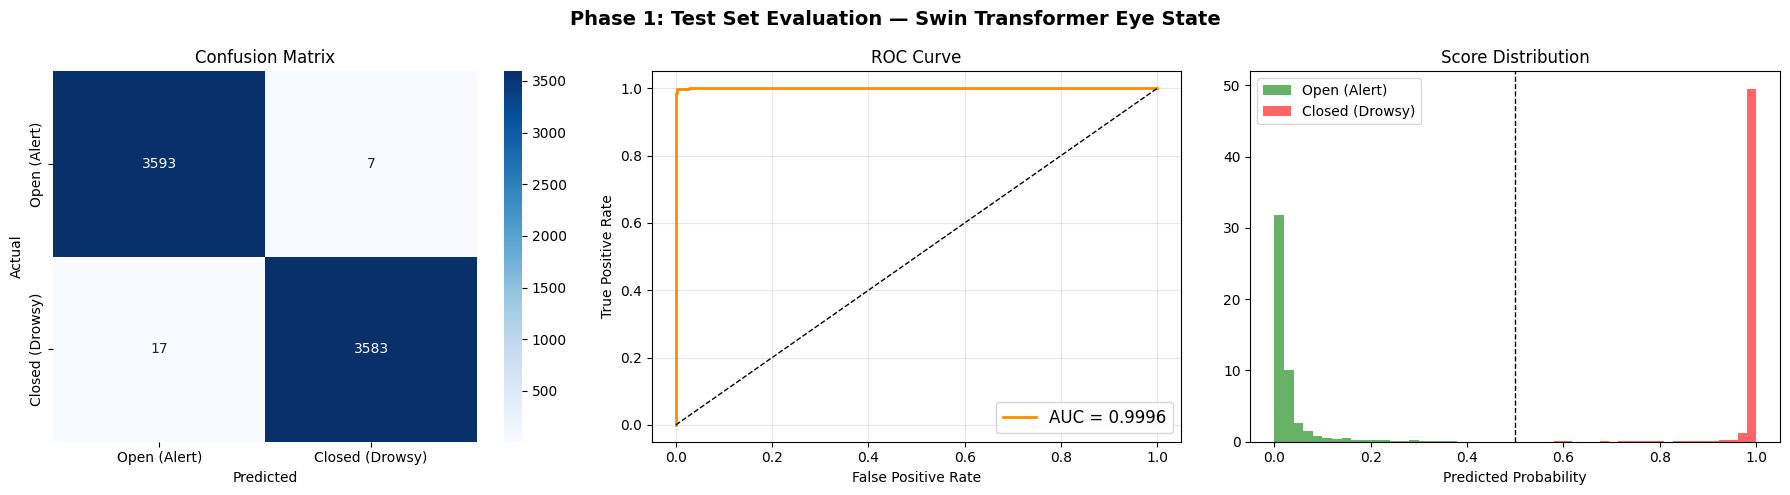


                 precision    recall  f1-score   support

   Open (Alert)       1.00      1.00      1.00      3600
Closed (Drowsy)       1.00      1.00      1.00      3600

       accuracy                           1.00      7200
      macro avg       1.00      1.00      1.00      7200
   weighted avg       1.00      1.00      1.00      7200

✅ Phase 1 COMPLETE — Branch A validated!


In [25]:
# ============================================================
# CELL 14: Load Best Model & Evaluate (FINAL FIX)
# ============================================================
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, 
                             precision_score, recall_score, confusion_matrix,
                             classification_report, roc_curve, auc as sk_auc)
import matplotlib.pyplot as plt
import seaborn as sns

# Load best checkpoint — weights_only=False is safe for our own files
checkpoint = torch.load(
    os.path.join(CFG.CHECKPOINT_DIR, 'best_swin_phase1.pth'),
    weights_only=False
)
swin_model.load_state_dict(checkpoint['model_state_dict'])
print(f"✅ Loaded best model from epoch {checkpoint['epoch']}")
print(f"   Val AUC: {checkpoint['val_auc']:.4f} | Val F1: {checkpoint['val_f1']:.4f}")

# Evaluate on test set
swin_model.eval()
all_preds, all_probs, all_labels = [], [], []

with torch.no_grad():
    for images, targets in test_loader:
        images = images.to(CFG.DEVICE)
        logits = swin_model(images)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()
        all_preds.extend(preds.cpu().numpy().flatten())
        all_probs.extend(probs.cpu().numpy().flatten())
        all_labels.extend(targets.numpy().flatten())

test_acc = accuracy_score(all_labels, all_preds)
test_f1 = f1_score(all_labels, all_preds)
test_prec = precision_score(all_labels, all_preds)
test_rec = recall_score(all_labels, all_preds)
test_auc = roc_auc_score(all_labels, all_probs)

print(f"\n{'=' * 50}")
print(f"  TEST SET RESULTS ({len(test_ds):,} images)")
print(f"{'=' * 50}")
print(f"  Accuracy  : {test_acc:.4f}")
print(f"  F1 Score  : {test_f1:.4f}")
print(f"  Precision : {test_prec:.4f}")
print(f"  Recall    : {test_rec:.4f}")
print(f"  AUC-ROC   : {test_auc:.4f}")

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Phase 1: Test Set Evaluation — Swin Transformer Eye State', fontsize=14, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Open (Alert)', 'Closed (Drowsy)'],
            yticklabels=['Open (Alert)', 'Closed (Drowsy)'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix')

# ROC Curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc_val = sk_auc(fpr, tpr)
axes[1].plot(fpr, tpr, 'darkorange', linewidth=2, label=f'AUC = {roc_auc_val:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

# Score Distribution
axes[2].hist([p for p, l in zip(all_probs, all_labels) if l == 0],
             bins=50, alpha=0.6, color='green', label='Open (Alert)', density=True)
axes[2].hist([p for p, l in zip(all_probs, all_labels) if l == 1],
             bins=50, alpha=0.6, color='red', label='Closed (Drowsy)', density=True)
axes[2].axvline(x=0.5, color='black', linestyle='--', linewidth=1)
axes[2].set_xlabel('Predicted Probability')
axes[2].set_title('Score Distribution')
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(CFG.OUTPUT_DIR, 'phase1_test_eval.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n" + classification_report(all_labels, all_preds, 
                                    target_names=['Open (Alert)', 'Closed (Drowsy)']))
print("✅ Phase 1 COMPLETE — Branch A validated!")

In [26]:
# ============================================================
# CELL 15: YOLOv8 Face Detection Setup
# ============================================================
from ultralytics import YOLO

# Load YOLOv8-nano (pretrained on COCO — includes "person" class)
# We'll use it for face region detection
yolo_model = YOLO('yolov8n.pt')
print(f"✅ YOLOv8n loaded")

# Test on a sample NTHU image
nthu_drowsy_dir = '/kaggle/input/datasets/ikhlaselhamly/nthu-ddd/NTHU-DDD/drowsy'
nthu_alert_dir = '/kaggle/input/datasets/ikhlaselhamly/nthu-ddd/NTHU-DDD/notdrowsy'

sample_img_path = os.path.join(nthu_drowsy_dir, os.listdir(nthu_drowsy_dir)[0])
sample_img = cv2.imread(sample_img_path)
print(f"   Sample image: {sample_img.shape}")

# YOLOv8 detection — class 0 = "person"
results = yolo_model(sample_img, verbose=False, conf=0.3)
detections = results[0].boxes

print(f"   Detections: {len(detections)} objects")
for box in detections:
    cls = int(box.cls[0])
    conf = float(box.conf[0])
    label = yolo_model.names[cls]
    print(f"     → {label}: {conf:.2f}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ YOLOv8n loaded
   Sample image: (480, 640, 3)
   Detections: 1 objects
     → person: 0.92


Testing face detection pipeline on NTHU-DDD samples...

Face detection rate: 98/100 (98.0%)


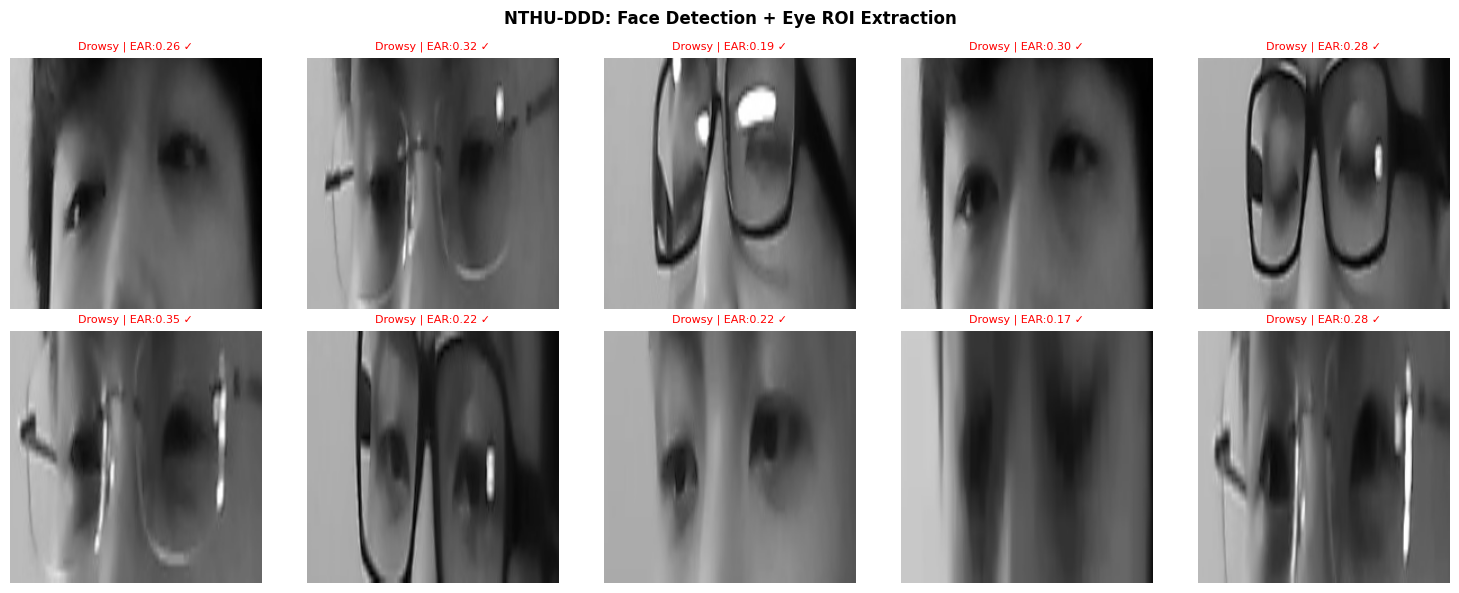

In [27]:
# ============================================================
# CELL 16: Robust Face/Landmark Pipeline for NTHU-DDD
# ============================================================
# NTHU-DDD images are full-face frames from real driving.
# Strategy: dlib face detector → 68 landmarks → features
# Fallback: if dlib fails, use full image center crop

def process_nthu_image(img_path, perclos_tracker=None):
    """
    Process a single NTHU-DDD image:
    1. Detect face with dlib
    2. Extract 68 landmarks  
    3. Crop eye ROI (for Branch A)
    4. Compute handcrafted features (for Branch B)
    
    Returns: eye_roi (224x224x3), features (7,), success (bool)
    """
    img = cv2.imread(img_path)
    if img is None:
        return None, None, False
    
    # Extract landmarks
    landmarks = extract_landmarks(img)
    
    if landmarks is None:
        # Fallback: use center crop as "face"
        h, w = img.shape[:2]
        cx, cy = w // 2, h // 2
        crop_size = min(h, w) // 2
        face_crop = img[max(0,cy-crop_size):cy+crop_size, max(0,cx-crop_size):cx+crop_size]
        eye_roi = cv2.resize(face_crop, (CFG.IMG_SIZE, CFG.IMG_SIZE))
        # Zero features when landmarks fail
        features = np.zeros(CFG.HANDCRAFTED_DIM, dtype=np.float32)
        return eye_roi, features, False
    
    # Extract eye ROI for Swin (Branch A)
    eye_roi = extract_eye_roi(img, landmarks, size=(CFG.IMG_SIZE, CFG.IMG_SIZE))
    
    # Compute handcrafted features (Branch B)
    if perclos_tracker is None:
        perclos_tracker = PERCLOSTracker()
    features = compute_features(landmarks, img.shape, perclos_tracker)
    
    return eye_roi, features, True

# --- Test the pipeline ---
print("Testing face detection pipeline on NTHU-DDD samples...\n")

success_count = 0
total_test = 100
perclos = PERCLOSTracker()

sample_files = os.listdir(nthu_drowsy_dir)[:total_test]
for f in sample_files:
    path = os.path.join(nthu_drowsy_dir, f)
    eye_roi, features, success = process_nthu_image(path, perclos)
    if success:
        success_count += 1

print(f"Face detection rate: {success_count}/{total_test} ({success_count/total_test*100:.1f}%)")

# Show some processed examples
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('NTHU-DDD: Face Detection + Eye ROI Extraction', fontweight='bold')

np.random.seed(42)
sample_paths = [os.path.join(nthu_drowsy_dir, f) for f in np.random.choice(os.listdir(nthu_drowsy_dir), 5)]
sample_paths += [os.path.join(nthu_alert_dir, f) for f in np.random.choice(os.listdir(nthu_alert_dir), 5)]

for i, path in enumerate(sample_paths):
    row, col = i // 5, i % 5
    eye_roi, features, success = process_nthu_image(path, PERCLOSTracker())
    if eye_roi is not None:
        eye_rgb = cv2.cvtColor(eye_roi, cv2.COLOR_BGR2RGB)
        axes[row, col].imshow(eye_rgb)
        label = "Drowsy" if "drowsy" in os.path.dirname(path) else "Alert"
        color = 'red' if label == "Drowsy" else 'green'
        ear_val = features[0] if features is not None else 0
        det = "✓" if success else "✗"
        axes[row, col].set_title(f'{label} | EAR:{ear_val:.2f} {det}', fontsize=8, color=color)
    axes[row, col].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(CFG.OUTPUT_DIR, 'nthu_pipeline_test.png'), dpi=100)
plt.show()

⏳ Preprocessing NTHU-DDD dataset (this takes ~10-15 min)...



Processing notdrowsy: 100%|██████████| 9000/9000 [06:56<00:00, 21.60it/s]



NTHU-DDD Preprocessing Complete
  Drowsy  : 9,000 images (face detected: 8,810)
  Alert   : 9,000 images (face detected: 8,556)
  Total   : 18,000
  Face detection rate: 96.5%

  Saved records to /kaggle/working/output/nthu_records.pkl


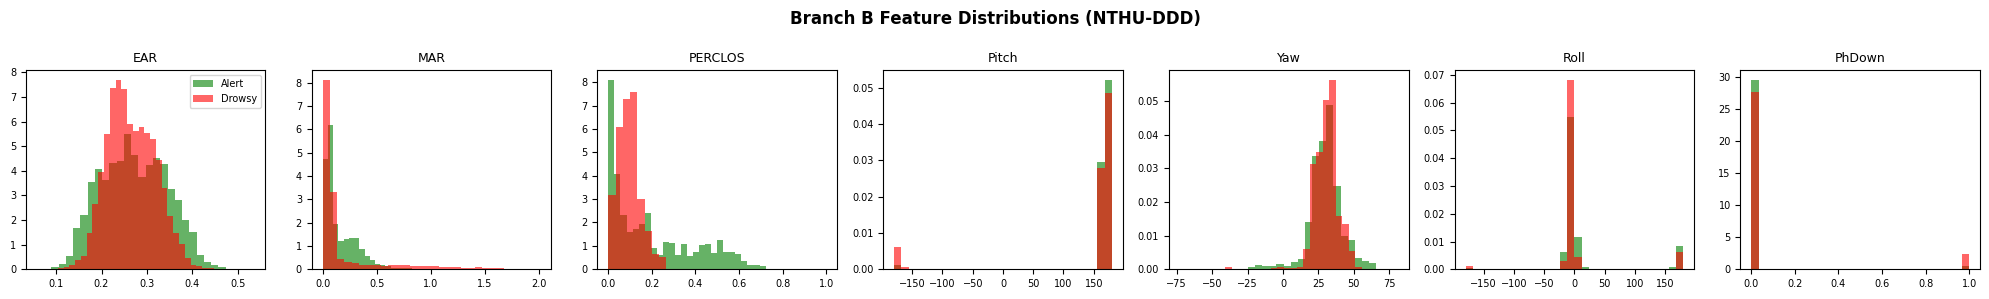

In [28]:
# ============================================================
# CELL 17: Preprocess ALL NTHU-DDD Images (Save features to disk)
# ============================================================
# This avoids recomputing landmarks during training — saves ~3x time
from tqdm import tqdm
import pickle

def preprocess_dataset(image_dir, label, perclos_tracker):
    """Process all images in a directory, return eye ROIs and features."""
    records = []
    files = sorted(os.listdir(image_dir))
    
    success = 0
    for fname in tqdm(files, desc=f"Processing {os.path.basename(image_dir)}"):
        if not fname.lower().endswith(('.jpg', '.png', '.jpeg')):
            continue
        
        path = os.path.join(image_dir, fname)
        eye_roi, features, detected = process_nthu_image(path, perclos_tracker)
        
        if eye_roi is not None:
            records.append({
                'path': path,
                'filename': fname,
                'label': label,
                'features': features,
                'face_detected': detected,
            })
            
            # Save eye ROI to disk (faster than re-extracting)
            roi_save_path = os.path.join(CFG.OUTPUT_DIR, 'nthu_eye_rois', 
                                          f"{'drowsy' if label == 1 else 'alert'}_{fname}")
            os.makedirs(os.path.dirname(roi_save_path), exist_ok=True)
            cv2.imwrite(roi_save_path, eye_roi)
            records[-1]['roi_path'] = roi_save_path
            
            if detected:
                success += 1
    
    return records, success

# Process both classes
perclos_drowsy = PERCLOSTracker()
perclos_alert = PERCLOSTracker()

print("⏳ Preprocessing NTHU-DDD dataset (this takes ~10-15 min)...\n")

drowsy_records, drowsy_success = preprocess_dataset(nthu_drowsy_dir, label=1, perclos_tracker=perclos_drowsy)
alert_records, alert_success = preprocess_dataset(nthu_alert_dir, label=0, perclos_tracker=perclos_alert)

all_records = drowsy_records + alert_records

print(f"\n{'=' * 50}")
print(f"NTHU-DDD Preprocessing Complete")
print(f"{'=' * 50}")
print(f"  Drowsy  : {len(drowsy_records):,} images (face detected: {drowsy_success:,})")
print(f"  Alert   : {len(alert_records):,} images (face detected: {alert_success:,})")
print(f"  Total   : {len(all_records):,}")
print(f"  Face detection rate: {(drowsy_success+alert_success)/len(all_records)*100:.1f}%")

# Save records
records_path = os.path.join(CFG.OUTPUT_DIR, 'nthu_records.pkl')
with open(records_path, 'wb') as f:
    pickle.dump(all_records, f)
print(f"\n  Saved records to {records_path}")

# Show feature distributions
import matplotlib.pyplot as plt

drowsy_features = np.array([r['features'] for r in drowsy_records if r['face_detected']])
alert_features = np.array([r['features'] for r in alert_records if r['face_detected']])

feature_names = ['EAR', 'MAR', 'PERCLOS', 'Pitch', 'Yaw', 'Roll', 'PhDown']

fig, axes = plt.subplots(1, 7, figsize=(20, 3))
fig.suptitle('Branch B Feature Distributions (NTHU-DDD)', fontweight='bold', fontsize=12)

for i, (name, ax) in enumerate(zip(feature_names, axes)):
    if len(drowsy_features) > 0:
        ax.hist(alert_features[:, i], bins=30, alpha=0.6, color='green', label='Alert', density=True)
        ax.hist(drowsy_features[:, i], bins=30, alpha=0.6, color='red', label='Drowsy', density=True)
    ax.set_title(name, fontsize=9)
    ax.tick_params(labelsize=7)
    if i == 0:
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(CFG.OUTPUT_DIR, 'nthu_feature_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# ============================================================
# CELL 18: NTHU-DDD Dataset Class + DataLoaders
# ============================================================

class NTHUDataset(Dataset):
    """
    NTHU-DDD dataset: loads precomputed eye ROIs + handcrafted features.
    Returns both for dual-branch model testing.
    """
    def __init__(self, records, transform=None):
        self.records = [r for r in records if 'roi_path' in r]
        self.transform = transform
    
    def __len__(self):
        return len(self.records)
    
    def __getitem__(self, idx):
        rec = self.records[idx]
        
        # Load eye ROI
        img = cv2.imread(rec['roi_path'])
        if img is None:
            img = np.zeros((CFG.IMG_SIZE, CFG.IMG_SIZE, 3), dtype=np.uint8)
        
        if len(img.shape) == 2:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        if self.transform:
            img = self.transform(img)
        
        # Handcrafted features
        features = torch.tensor(rec['features'], dtype=torch.float32)
        
        # Label
        label = torch.tensor(rec['label'], dtype=torch.float32)
        
        return img, features, label

# Split
from sklearn.model_selection import train_test_split

nthu_train_rec, nthu_temp_rec = train_test_split(
    all_records, test_size=0.30, random_state=CFG.SEED,
    stratify=[r['label'] for r in all_records]
)
nthu_val_rec, nthu_test_rec = train_test_split(
    nthu_temp_rec, test_size=0.50, random_state=CFG.SEED,
    stratify=[r['label'] for r in nthu_temp_rec]
)

nthu_train_ds = NTHUDataset(nthu_train_rec, train_transforms)
nthu_val_ds   = NTHUDataset(nthu_val_rec, val_transforms)
nthu_test_ds  = NTHUDataset(nthu_test_rec, val_transforms)

nthu_train_loader = DataLoader(nthu_train_ds, batch_size=CFG.BATCH_SIZE, shuffle=True,
                                num_workers=CFG.NUM_WORKERS, pin_memory=True, drop_last=True)
nthu_val_loader   = DataLoader(nthu_val_ds, batch_size=CFG.BATCH_SIZE, shuffle=False,
                                num_workers=CFG.NUM_WORKERS, pin_memory=True)
nthu_test_loader  = DataLoader(nthu_test_ds, batch_size=CFG.BATCH_SIZE, shuffle=False,
                                num_workers=CFG.NUM_WORKERS, pin_memory=True)

print(f"✅ NTHU-DDD DataLoaders ready")
print(f"   Train: {len(nthu_train_ds):,} | Val: {len(nthu_val_ds):,} | Test: {len(nthu_test_ds):,}")

# Sanity check
img_batch, feat_batch, lbl_batch = next(iter(nthu_train_loader))
print(f"   Image batch : {img_batch.shape}")
print(f"   Feature batch: {feat_batch.shape}")
print(f"   Label batch  : {lbl_batch.shape}")

✅ NTHU-DDD DataLoaders ready
   Train: 12,600 | Val: 2,700 | Test: 2,700
   Image batch : torch.Size([32, 3, 224, 224])
   Feature batch: torch.Size([32, 7])
   Label batch  : torch.Size([32])


In [30]:
# ============================================================
# CELL 19: HybridDDS v1 — Dual Branch Fusion (Frame-level, no LSTM)
# ============================================================
import timm

class HybridDDS_v1(nn.Module):
    """
    Dual-branch drowsiness detector (frame-level):
    - Branch A: Swin Transformer (pretrained from Phase 1)
    - Branch B: Handcrafted feature MLP (EAR, MAR, PERCLOS, head pose)
    - Fusion: Concatenation + FC layers
    """
    def __init__(self, handcrafted_dim=CFG.HANDCRAFTED_DIM, dropout=CFG.DROPOUT):
        super().__init__()
        
        # ─── Branch A: Swin Transformer ───
        self.branch_a = timm.create_model(
            'swin_tiny_patch4_window7_224',
            pretrained=False,
            num_classes=0
        )
        swin_dim = 768
        
        # ─── Branch B: Handcrafted Feature MLP ───
        self.branch_b = nn.Sequential(
            nn.Linear(handcrafted_dim, 64),
            nn.GELU(),
            nn.BatchNorm1d(64),
            nn.Dropout(dropout),
            nn.Linear(64, 128),
            nn.GELU(),
            nn.BatchNorm1d(128),
        )
        branch_b_dim = 128
        
        # ─── Fusion Head ───
        fused_dim = swin_dim + branch_b_dim  # 768 + 128 = 896
        self.fusion = nn.Sequential(
            nn.Linear(fused_dim, 256),
            nn.GELU(),
            nn.BatchNorm1d(256),
            nn.Dropout(dropout),
            nn.Linear(256, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )
    
    def forward(self, images, features):
        visual = self.branch_a(images)          # (B, 768)
        handcrafted = self.branch_b(features)   # (B, 128)
        fused = torch.cat([visual, handcrafted], dim=1)  # (B, 896)
        logits = self.fusion(fused)             # (B, 1)
        return logits

# Build model
hybrid_v1 = HybridDDS_v1().to(CFG.DEVICE)

# Load Phase 1 Swin weights into Branch A — FIXED: weights_only=False
phase1_checkpoint = torch.load(
    os.path.join(CFG.CHECKPOINT_DIR, 'best_swin_phase1.pth'),
    weights_only=False
)
swin_state = {k.replace('backbone.', ''): v 
              for k, v in phase1_checkpoint['model_state_dict'].items() 
              if k.startswith('backbone.')}
hybrid_v1.branch_a.load_state_dict(swin_state, strict=True)
print(f"✅ Loaded Phase 1 Swin weights into Branch A (epoch {phase1_checkpoint['epoch']})")

# Parameter count
total = sum(p.numel() for p in hybrid_v1.parameters())
branch_a_p = sum(p.numel() for p in hybrid_v1.branch_a.parameters())
branch_b_p = sum(p.numel() for p in hybrid_v1.branch_b.parameters())
fusion_p = sum(p.numel() for p in hybrid_v1.fusion.parameters())

print(f"✅ HybridDDS v1 built (frame-level, dual-branch)")
print(f"   Total       : {total:>10,} ({total/1e6:.1f}M)")
print(f"   Branch A    : {branch_a_p:>10,} ({branch_a_p/1e6:.1f}M) [Swin, pretrained]")
print(f"   Branch B    : {branch_b_p:>10,} ({branch_b_p/1e6:.1f}M) [Handcrafted MLP]")
print(f"   Fusion Head : {fusion_p:>10,} ({fusion_p/1e6:.1f}M)")

# Quick test
with torch.no_grad():
    test_img = torch.randn(4, 3, 224, 224).to(CFG.DEVICE)
    test_feat = torch.randn(4, 7).to(CFG.DEVICE)
    out = hybrid_v1(test_img, test_feat)
    print(f"\n   Test forward: images {test_img.shape} + features {test_feat.shape} → {out.shape}")

✅ Loaded Phase 1 Swin weights into Branch A (epoch 11)
✅ HybridDDS v1 built (frame-level, dual-branch)
   Total       : 27,775,227 (27.8M)
   Branch A    : 27,519,354 (27.5M) [Swin, pretrained]
   Branch B    :      9,216 (0.0M) [Handcrafted MLP]
   Fusion Head :    246,657 (0.2M)

   Test forward: images torch.Size([4, 3, 224, 224]) + features torch.Size([4, 7]) → torch.Size([4, 1])


In [31]:
# ============================================================
# CELL 20: Train HybridDDS v1 on NTHU-DDD (18K images)
# ============================================================
from torch.cuda.amp import GradScaler, autocast

# Optimizer with 3 param groups
optimizer_h = AdamW([
    {'params': hybrid_v1.branch_a.parameters(), 'lr': CFG.BACKBONE_LR * 0.5},  # 5e-6
    {'params': hybrid_v1.branch_b.parameters(), 'lr': CFG.LR},                  # 1e-4
    {'params': hybrid_v1.fusion.parameters(),   'lr': CFG.LR},                  # 1e-4
], weight_decay=CFG.WEIGHT_DECAY)

scheduler_h = CosineAnnealingWarmRestarts(optimizer_h, T_0=5, T_mult=2, eta_min=1e-7)
criterion_h = FocalBCELoss(alpha=0.25, gamma=2.0)
scaler = GradScaler()

# ─── Training function (dual-branch) ───
def train_hybrid_epoch(model, loader, optimizer, criterion, device, scaler):
    model.train()
    running_loss = 0
    all_preds, all_labels = [], []
    
    for images, features, targets in loader:
        images = images.to(device, non_blocking=True)
        features = features.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True).unsqueeze(1)
        
        optimizer.zero_grad()
        
        with autocast():
            logits = model(images, features)
            loss = criterion(logits, targets)
        
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item() * images.size(0)
        preds = (torch.sigmoid(logits.float()) > 0.5).float()
        all_preds.extend(preds.detach().cpu().numpy().flatten())
        all_labels.extend(targets.cpu().numpy().flatten())
    
    avg_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    return avg_loss, acc, f1

# ─── Validation function (dual-branch) ───
@torch.no_grad()
def validate_hybrid(model, loader, criterion, device):
    model.eval()
    running_loss = 0
    all_preds, all_probs, all_labels = [], [], []
    
    for images, features, targets in loader:
        images = images.to(device, non_blocking=True)
        features = features.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True).unsqueeze(1)
        
        with autocast():
            logits = model(images, features)
            loss = criterion(logits, targets)
        
        running_loss += loss.item() * images.size(0)
        probs = torch.sigmoid(logits.float())
        preds = (probs > 0.5).float()
        all_preds.extend(preds.cpu().numpy().flatten())
        all_probs.extend(probs.cpu().numpy().flatten())
        all_labels.extend(targets.cpu().numpy().flatten())
    
    avg_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    auc = roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0
    return avg_loss, acc, f1, auc

# ─── Training Loop ───
best_auc_h = 0
best_f1_h = 0
patience_h = 0
history_h = {'train_loss': [], 'train_acc': [], 'train_f1': [],
             'val_loss': [], 'val_acc': [], 'val_f1': [], 'val_auc': []}

print("=" * 80)
print("  PHASE 2: TRAINING HybridDDS v1 — DUAL BRANCH ON NTHU-DDD")
print(f"  {len(nthu_train_ds):,} train | {len(nthu_val_ds):,} val | {len(nthu_test_ds):,} test")
print(f"  Mixed Precision: ON | Pretrained Swin: Phase 1 weights")
print("=" * 80)

total_start = time.time()

for epoch in range(CFG.EPOCHS):
    epoch_start = time.time()
    
    train_loss, train_acc, train_f1 = train_hybrid_epoch(
        hybrid_v1, nthu_train_loader, optimizer_h, criterion_h, CFG.DEVICE, scaler
    )
    val_loss, val_acc, val_f1, val_auc = validate_hybrid(
        hybrid_v1, nthu_val_loader, criterion_h, CFG.DEVICE
    )
    scheduler_h.step(epoch + val_loss)
    
    elapsed = time.time() - epoch_start
    
    history_h['train_loss'].append(train_loss)
    history_h['train_acc'].append(train_acc)
    history_h['train_f1'].append(train_f1)
    history_h['val_loss'].append(val_loss)
    history_h['val_acc'].append(val_acc)
    history_h['val_f1'].append(val_f1)
    history_h['val_auc'].append(val_auc)
    
    print(f"Epoch {epoch+1:02d}/{CFG.EPOCHS} │ "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} F1: {train_f1:.4f} │ "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1: {val_f1:.4f} "
          f"AUC: {val_auc:.4f} │ {elapsed:.1f}s")
    
    # Save best
    improved = False
    if val_auc > best_auc_h:
        best_auc_h = val_auc
        improved = True
    if val_f1 > best_f1_h:
        best_f1_h = val_f1
        improved = True
    
    if improved:
        patience_h = 0
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': hybrid_v1.state_dict(),
            'optimizer_state_dict': optimizer_h.state_dict(),
            'val_auc': val_auc,
            'val_f1': val_f1,
            'val_acc': val_acc,
            'history': history_h,
        }, os.path.join(CFG.CHECKPOINT_DIR, 'best_hybrid_v1.pth'))
        print(f"  ✅ Saved best model (AUC: {best_auc_h:.4f}, F1: {best_f1_h:.4f})")
    else:
        patience_h += 1
        if patience_h >= CFG.PATIENCE:
            print(f"\n  ⏹ Early stopping at epoch {epoch+1}")
            break

total_time = time.time() - total_start
print(f"\n{'=' * 80}")
print(f"  Phase 2 complete in {total_time/60:.1f} minutes")
print(f"  Best Val AUC: {best_auc_h:.4f} | Best Val F1: {best_f1_h:.4f}")
print(f"{'=' * 80}")

# ─── Quick Phase 2 Evaluation on Test Set ───
print("\n⏳ Evaluating on NTHU-DDD test set...")

# Load best
best_h = torch.load(
    os.path.join(CFG.CHECKPOINT_DIR, 'best_hybrid_v1.pth'),
    weights_only=False
)
hybrid_v1.load_state_dict(best_h['model_state_dict'])

test_loss_h, test_acc_h, test_f1_h, test_auc_h = validate_hybrid(
    hybrid_v1, nthu_test_loader, criterion_h, CFG.DEVICE
)

print(f"\n{'=' * 50}")
print(f"  PHASE 2 TEST RESULTS ({len(nthu_test_ds):,} images)")
print(f"{'=' * 50}")
print(f"  Accuracy : {test_acc_h:.4f}")
print(f"  F1 Score : {test_f1_h:.4f}")
print(f"  AUC-ROC  : {test_auc_h:.4f}")

# ─── Training curves ───
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Phase 2: HybridDDS v1 Training on NTHU-DDD', fontweight='bold')

ep = range(1, len(history_h['train_loss']) + 1)

axes[0].plot(ep, history_h['train_loss'], 'b-', label='Train')
axes[0].plot(ep, history_h['val_loss'], 'r-', label='Val')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(ep, history_h['train_acc'], 'b-', label='Train')
axes[1].plot(ep, history_h['val_acc'], 'r-', label='Val')
axes[1].set_title('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(ep, history_h['val_f1'], 'g-', label='F1', linewidth=2)
axes[2].plot(ep, history_h['val_auc'], 'darkorange', label='AUC', linewidth=2)
axes[2].set_title('Val F1 & AUC')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CFG.OUTPUT_DIR, 'phase2_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Phase 2 COMPLETE — Dual-branch fusion validated on real driving data!")

  PHASE 2: TRAINING HybridDDS v1 — DUAL BRANCH ON NTHU-DDD
  12,600 train | 2,700 val | 2,700 test
  Mixed Precision: ON | Pretrained Swin: Phase 1 weights
Epoch 01/50 │ Train Loss: 0.0325 Acc: 0.7389 F1: 0.7403 │ Val Loss: 0.0242 Acc: 0.8296 F1: 0.8428 AUC: 0.9214 │ 85.8s
  ✅ Saved best model (AUC: 0.9214, F1: 0.8428)
Epoch 02/50 │ Train Loss: 0.0251 Acc: 0.8186 F1: 0.8214 │ Val Loss: 0.0205 Acc: 0.8711 F1: 0.8765 AUC: 0.9401 │ 86.0s
  ✅ Saved best model (AUC: 0.9401, F1: 0.8765)
Epoch 03/50 │ Train Loss: 0.0221 Acc: 0.8464 F1: 0.8494 │ Val Loss: 0.0183 Acc: 0.8837 F1: 0.8904 AUC: 0.9537 │ 86.1s
  ✅ Saved best model (AUC: 0.9537, F1: 0.8904)
Epoch 04/50 │ Train Loss: 0.0203 Acc: 0.8618 F1: 0.8641 │ Val Loss: 0.0184 Acc: 0.8744 F1: 0.8847 AUC: 0.9587 │ 86.3s
  ✅ Saved best model (AUC: 0.9587, F1: 0.8904)
Epoch 05/50 │ Train Loss: 0.0190 Acc: 0.8709 F1: 0.8735 │ Val Loss: 0.0152 Acc: 0.9019 F1: 0.9047 AUC: 0.9680 │ 86.4s
  ✅ Saved best model (AUC: 0.9680, F1: 0.9047)
Epoch 06/50 │ Train

KeyboardInterrupt: 

Found 349 videos


Extracting YawDD frames: 100%|██████████| 349/349 [01:34<00:00,  3.71it/s]



YawDD Frame Extraction Complete
  Total frames : 19,170
  Alert (0)    : 12,293
  Drowsy (1)   : 6,877


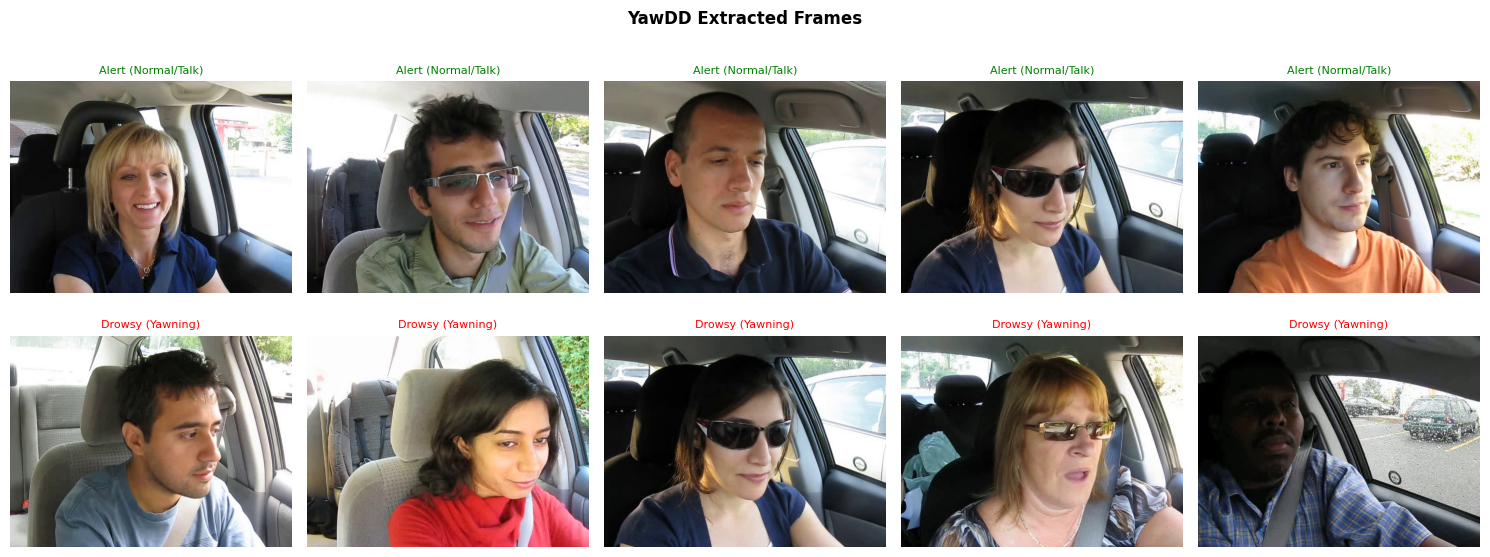

✅ Phase 3 frame extraction complete!


In [32]:
# ============================================================
# CELL 21: Phase 3 — Extract YawDD Video Frames + Labels
# ============================================================
from tqdm import tqdm
import re

yawdd_base = '/kaggle/input/notebooks/rifqinaufalabdjul/yawdd-dataset/YawDD dataset'

# YawDD video filenames contain labels: "Normal", "Yawning", "Talking"
# We map: Normal/Talking → 0 (alert), Yawning → 1 (drowsy)

def get_yawdd_label(filename):
    fname = filename.lower()
    if 'yawning' in fname:
        return 1  # drowsy
    elif 'normal' in fname or 'talking' in fname:
        return 0  # alert
    return -1  # unknown

def extract_video_frames(video_path, output_dir, label, max_frames=60, sample_rate=5):
    """
    Extract frames from video at given sample rate.
    sample_rate=5 means every 5th frame (~6fps from 30fps video).
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return []
    
    records = []
    frame_idx = 0
    saved = 0
    vid_name = os.path.splitext(os.path.basename(video_path))[0]
    
    while saved < max_frames:
        ret, frame = cap.read()
        if not ret:
            break
        
        if frame_idx % sample_rate == 0:
            # Save frame
            fname = f"{vid_name}_f{frame_idx:05d}.jpg"
            save_path = os.path.join(output_dir, fname)
            cv2.imwrite(save_path, frame)
            
            records.append({
                'path': save_path,
                'filename': fname,
                'label': label,
                'video_source': os.path.basename(video_path),
                'frame_idx': frame_idx,
            })
            saved += 1
        
        frame_idx += 1
    
    cap.release()
    return records

# Create output directory
yawdd_frames_dir = os.path.join(CFG.OUTPUT_DIR, 'yawdd_frames')
os.makedirs(yawdd_frames_dir, exist_ok=True)

# Find all AVI files
avi_files = []
for root, dirs, files in os.walk(yawdd_base):
    for f in files:
        if f.lower().endswith('.avi'):
            avi_files.append(os.path.join(root, f))

print(f"Found {len(avi_files)} videos")

# Process all videos
all_yawdd_records = []
label_counts = {0: 0, 1: 0}

for vid_path in tqdm(avi_files, desc="Extracting YawDD frames"):
    label = get_yawdd_label(os.path.basename(vid_path))
    if label == -1:
        continue
    
    records = extract_video_frames(
        vid_path, yawdd_frames_dir, label, 
        max_frames=60, sample_rate=5
    )
    all_yawdd_records.extend(records)
    label_counts[label] += len(records)

print(f"\n{'=' * 50}")
print(f"YawDD Frame Extraction Complete")
print(f"{'=' * 50}")
print(f"  Total frames : {len(all_yawdd_records):,}")
print(f"  Alert (0)    : {label_counts[0]:,}")
print(f"  Drowsy (1)   : {label_counts[1]:,}")

# Show samples
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('YawDD Extracted Frames', fontweight='bold')

alert_recs = [r for r in all_yawdd_records if r['label'] == 0]
drowsy_recs = [r for r in all_yawdd_records if r['label'] == 1]

np.random.seed(42)
for col in range(5):
    if alert_recs:
        rec = alert_recs[np.random.randint(len(alert_recs))]
        img = cv2.imread(rec['path'])
        if img is not None:
            axes[0, col].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[0, col].set_title('Alert (Normal/Talk)', fontsize=8, color='green')
        axes[0, col].axis('off')
    
    if drowsy_recs:
        rec = drowsy_recs[np.random.randint(len(drowsy_recs))]
        img = cv2.imread(rec['path'])
        if img is not None:
            axes[1, col].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[1, col].set_title('Drowsy (Yawning)', fontsize=8, color='red')
        axes[1, col].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(CFG.OUTPUT_DIR, 'yawdd_samples_extracted.png'), dpi=100)
plt.show()

print("✅ Phase 3 frame extraction complete!")

In [33]:
# ============================================================
# CELL 22: Process YawDD Frames — Landmarks + Eye ROI + Features
# ============================================================

yawdd_roi_dir = os.path.join(CFG.OUTPUT_DIR, 'yawdd_eye_rois')
os.makedirs(yawdd_roi_dir, exist_ok=True)

processed_yawdd = []
success_count = 0

for rec in tqdm(all_yawdd_records, desc="Processing YawDD landmarks"):
    img = cv2.imread(rec['path'])
    if img is None:
        continue
    
    landmarks = extract_landmarks(img)
    
    if landmarks is not None:
        eye_roi = extract_eye_roi(img, landmarks, size=(CFG.IMG_SIZE, CFG.IMG_SIZE))
        perclos_t = PERCLOSTracker()
        features = compute_features(landmarks, img.shape, perclos_t)
        success_count += 1
        detected = True
    else:
        # Fallback: center crop
        h, w = img.shape[:2]
        cx, cy = w // 2, h // 2
        cs = min(h, w) // 3
        eye_roi = img[max(0,cy-cs):cy+cs, max(0,cx-cs):cx+cs]
        eye_roi = cv2.resize(eye_roi, (CFG.IMG_SIZE, CFG.IMG_SIZE))
        features = np.zeros(CFG.HANDCRAFTED_DIM, dtype=np.float32)
        detected = False
    
    # Save ROI
    roi_fname = f"{'drowsy' if rec['label']==1 else 'alert'}_{rec['filename']}"
    roi_path = os.path.join(yawdd_roi_dir, roi_fname)
    cv2.imwrite(roi_path, eye_roi)
    
    processed_yawdd.append({
        'path': rec['path'],
        'roi_path': roi_path,
        'label': rec['label'],
        'features': features,
        'face_detected': detected,
        'video_source': rec['video_source'],
    })

print(f"\n✅ YawDD processing complete")
print(f"   Processed: {len(processed_yawdd):,} frames")
print(f"   Face detected: {success_count:,} ({success_count/max(len(processed_yawdd),1)*100:.1f}%)")

Processing YawDD landmarks: 100%|██████████| 19170/19170 [11:45<00:00, 27.18it/s]


✅ YawDD processing complete
   Processed: 19,170 frames
   Face detected: 13,423 (70.0%)


In [34]:
# ============================================================
# CELL 23: Phase 4 — Full HybridDDS with LSTM Temporal Modeling
# ============================================================

class HybridDDS_Full(nn.Module):
    """
    Full HybridDDS: Dual-Branch + LSTM Temporal Modeling
    
    Branch A: Swin Transformer (768-dim visual features)
    Branch B: Handcrafted MLP (128-dim physiological features)
    Fusion → LSTM (temporal context over SEQ_LEN frames) → Drowsiness Score
    """
    def __init__(self, 
                 handcrafted_dim=CFG.HANDCRAFTED_DIM,
                 lstm_hidden=CFG.LSTM_HIDDEN,
                 lstm_layers=CFG.LSTM_LAYERS,
                 dropout=CFG.DROPOUT):
        super().__init__()
        
        # ─── Branch A: Swin Transformer ───
        self.branch_a = timm.create_model(
            'swin_tiny_patch4_window7_224',
            pretrained=False,
            num_classes=0
        )
        swin_dim = 768
        
        # ─── Branch B: Handcrafted Feature MLP ───
        self.branch_b = nn.Sequential(
            nn.Linear(handcrafted_dim, 64),
            nn.GELU(),
            nn.BatchNorm1d(64),
            nn.Dropout(dropout),
            nn.Linear(64, 128),
            nn.GELU(),
            nn.BatchNorm1d(128),
        )
        branch_b_dim = 128
        
        # ─── Feature Fusion ───
        fused_dim = swin_dim + branch_b_dim  # 896
        self.fusion = nn.Sequential(
            nn.Linear(fused_dim, 256),
            nn.GELU(),
            nn.BatchNorm1d(256),
            nn.Dropout(dropout),
        )
        
        # ─── LSTM Temporal Modeling ───
        self.lstm = nn.LSTM(
            input_size=256,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=dropout if lstm_layers > 1 else 0,
        )
        
        # ─── Output Head ───
        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden, 32),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )
    
    def forward(self, eye_roi_seq, handcrafted_seq):
        """
        Args:
            eye_roi_seq:     (B, T, 3, 224, 224) — sequence of eye ROI images
            handcrafted_seq: (B, T, 7)           — sequence of handcrafted features
        Returns:
            logits: (B, 1) — drowsiness score (pre-sigmoid)
        """
        B, T = eye_roi_seq.shape[:2]
        
        # Flatten for batch processing through branches
        eye_flat = eye_roi_seq.view(B * T, 3, CFG.IMG_SIZE, CFG.IMG_SIZE)
        hc_flat = handcrafted_seq.view(B * T, -1)
        
        # Branch A
        visual = self.branch_a(eye_flat)        # (B*T, 768)
        
        # Branch B
        handcrafted = self.branch_b(hc_flat)    # (B*T, 128)
        
        # Fuse
        fused = torch.cat([visual, handcrafted], dim=1)  # (B*T, 896)
        fused = self.fusion(fused)               # (B*T, 256)
        
        # Reshape to sequence
        fused = fused.view(B, T, -1)             # (B, T, 256)
        
        # LSTM
        lstm_out, _ = self.lstm(fused)           # (B, T, 64)
        last_hidden = lstm_out[:, -1, :]         # (B, 64) — last timestep
        
        # Classify
        logits = self.classifier(last_hidden)    # (B, 1)
        return logits

# Build full model
hybrid_full = HybridDDS_Full().to(CFG.DEVICE)

# Load Phase 2 weights (Branch A + Branch B + Fusion already trained)
phase2_checkpoint = torch.load(
    os.path.join(CFG.CHECKPOINT_DIR, 'best_hybrid_v1.pth'),
    weights_only=False
)

# Transfer matching weights from v1 → full model
v1_state = phase2_checkpoint['model_state_dict']
full_state = hybrid_full.state_dict()

transferred = 0
for key in v1_state:
    if key in full_state and v1_state[key].shape == full_state[key].shape:
        full_state[key] = v1_state[key]
        transferred += 1

hybrid_full.load_state_dict(full_state)
print(f"✅ Transferred {transferred} weight tensors from Phase 2 → Full model")

# Note: fusion layer in v1 ends with classifier, but in full model it ends at 256-dim
# The LSTM and final classifier are randomly initialized (new components)

total = sum(p.numel() for p in hybrid_full.parameters())
print(f"✅ HybridDDS Full Model built")
print(f"   Total params: {total:,} ({total/1e6:.1f}M)")
print(f"   LSTM: {CFG.LSTM_HIDDEN} hidden, {CFG.LSTM_LAYERS} layer(s)")

# Quick test with reduced sequence length for speed
SEQ_LEN_TRAIN = 10  # Use 10 for training (faster), 50 for final eval
with torch.no_grad():
    dummy_eye = torch.randn(2, SEQ_LEN_TRAIN, 3, 224, 224).to(CFG.DEVICE)
    dummy_hc = torch.randn(2, SEQ_LEN_TRAIN, 7).to(CFG.DEVICE)
    out = hybrid_full(dummy_eye, dummy_hc)
    print(f"   Test: eye_seq {dummy_eye.shape} + feat_seq {dummy_hc.shape} → {out.shape}")

✅ Transferred 192 weight tensors from Phase 2 → Full model
✅ HybridDDS Full Model built
   Total params: 27,843,259 (27.8M)
   LSTM: 64 hidden, 1 layer(s)
   Test: eye_seq torch.Size([2, 10, 3, 224, 224]) + feat_seq torch.Size([2, 10, 7]) → torch.Size([2, 1])


In [35]:
# ============================================================
# CELL 24: Temporal Sequence Dataset (All 3 Datasets Combined)
# ============================================================

SEQ_LEN_TRAIN = 10  # Shorter sequences for training speed on T4

class TemporalDrowsinessDataset(Dataset):
    """
    Creates temporal sequences from frame-level records.
    Groups frames by video/subject, creates sliding window sequences.
    For image datasets (no video), creates pseudo-sequences from same class.
    """
    def __init__(self, records, seq_len=SEQ_LEN_TRAIN, transform=None):
        self.records = [r for r in records if 'roi_path' in r]
        self.seq_len = seq_len
        self.transform = transform
        self.sequences = self._build_sequences()
    
    def _build_sequences(self):
        """Build sequences of consecutive frames."""
        sequences = []
        
        # Group by video source (if available) or by label
        from collections import defaultdict
        groups = defaultdict(list)
        
        for rec in self.records:
            key = rec.get('video_source', f"class_{rec['label']}")
            groups[key].append(rec)
        
        for key, recs in groups.items():
            # Sort by filename to maintain temporal order
            recs = sorted(recs, key=lambda x: x.get('filename', ''))
            
            if len(recs) >= self.seq_len:
                # Sliding window
                for i in range(0, len(recs) - self.seq_len + 1, self.seq_len // 2):
                    seq = recs[i:i + self.seq_len]
                    # Use majority label
                    labels = [r['label'] for r in seq]
                    majority_label = 1 if sum(labels) > len(labels) / 2 else 0
                    sequences.append((seq, majority_label))
            else:
                # Pad by repeating last frame
                padded = recs + [recs[-1]] * (self.seq_len - len(recs))
                labels = [r['label'] for r in recs]
                majority_label = 1 if sum(labels) > len(labels) / 2 else 0
                sequences.append((padded[:self.seq_len], majority_label))
        
        return sequences
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        seq_records, label = self.sequences[idx]
        
        eye_rois = []
        features_list = []
        
        for rec in seq_records:
            # Load eye ROI
            img = cv2.imread(rec['roi_path'])
            if img is None:
                img = np.zeros((CFG.IMG_SIZE, CFG.IMG_SIZE, 3), dtype=np.uint8)
            
            if len(img.shape) == 2:
                img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
            else:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            if self.transform:
                img = self.transform(img)
            else:
                img = transforms.ToTensor()(img)
            
            eye_rois.append(img)
            features_list.append(torch.tensor(rec['features'], dtype=torch.float32))
        
        eye_seq = torch.stack(eye_rois)           # (T, 3, 224, 224)
        feat_seq = torch.stack(features_list)     # (T, 7)
        label = torch.tensor(label, dtype=torch.float32)
        
        return eye_seq, feat_seq, label

# ─── Combine all datasets ───
print("Combining all datasets for temporal training...\n")

# All records from NTHU + YawDD (both have face ROIs and features)
combined_records = all_records + processed_yawdd  # NTHU + YawDD

# Split combined data
from sklearn.model_selection import train_test_split

combined_train, combined_temp = train_test_split(
    combined_records, test_size=0.3, random_state=CFG.SEED,
    stratify=[r['label'] for r in combined_records]
)
combined_val, combined_test = train_test_split(
    combined_temp, test_size=0.5, random_state=CFG.SEED,
    stratify=[r['label'] for r in combined_temp]
)

temporal_train_ds = TemporalDrowsinessDataset(combined_train, SEQ_LEN_TRAIN, val_transforms)
temporal_val_ds = TemporalDrowsinessDataset(combined_val, SEQ_LEN_TRAIN, val_transforms)
temporal_test_ds = TemporalDrowsinessDataset(combined_test, SEQ_LEN_TRAIN, val_transforms)

# Smaller batch size for sequences (memory heavy!)
SEQ_BATCH = 4

temporal_train_loader = DataLoader(temporal_train_ds, batch_size=SEQ_BATCH, shuffle=True,
                                    num_workers=CFG.NUM_WORKERS, pin_memory=True, drop_last=True)
temporal_val_loader = DataLoader(temporal_val_ds, batch_size=SEQ_BATCH, shuffle=False,
                                  num_workers=CFG.NUM_WORKERS, pin_memory=True)
temporal_test_loader = DataLoader(temporal_test_ds, batch_size=SEQ_BATCH, shuffle=False,
                                   num_workers=CFG.NUM_WORKERS, pin_memory=True)

print(f"✅ Temporal datasets ready (seq_len={SEQ_LEN_TRAIN})")
print(f"   Combined records: {len(combined_records):,} (NTHU: {len(all_records):,} + YawDD: {len(processed_yawdd):,})")
print(f"   Train sequences : {len(temporal_train_ds):,}")
print(f"   Val sequences   : {len(temporal_val_ds):,}")
print(f"   Test sequences  : {len(temporal_test_ds):,}")
print(f"   Batch size      : {SEQ_BATCH} (reduced for seq memory)")

# Sanity check
eye_batch, feat_batch, lbl_batch = next(iter(temporal_train_loader))
print(f"\n   Eye batch  : {eye_batch.shape}  (B, T, C, H, W)")
print(f"   Feat batch : {feat_batch.shape}  (B, T, 7)")
print(f"   Label batch: {lbl_batch.shape}")

Combining all datasets for temporal training...

✅ Temporal datasets ready (seq_len=10)
   Combined records: 37,170 (NTHU: 18,000 + YawDD: 19,170)
   Train sequences : 4,753
   Val sequences   : 867
   Test sequences  : 852
   Batch size      : 4 (reduced for seq memory)

   Eye batch  : torch.Size([4, 10, 3, 224, 224])  (B, T, C, H, W)
   Feat batch : torch.Size([4, 10, 7])  (B, T, 7)
   Label batch: torch.Size([4])


In [36]:
# ============================================================
# CELL 25: Phase 4 — Train Full HybridDDS (Temporal LSTM)
# ============================================================

# Freeze Branch A (Swin) — only train LSTM + classifier + fine-tune Branch B
for param in hybrid_full.branch_a.parameters():
    param.requires_grad = False

trainable_after_freeze = sum(p.numel() for p in hybrid_full.parameters() if p.requires_grad)
print(f"Frozen Branch A (Swin). Trainable params: {trainable_after_freeze:,} ({trainable_after_freeze/1e6:.1f}M)")

# Optimizer — only trainable params
optimizer_full = AdamW([
    {'params': hybrid_full.branch_b.parameters(), 'lr': CFG.LR * 0.5},     # 5e-5
    {'params': hybrid_full.fusion.parameters(),   'lr': CFG.LR},            # 1e-4
    {'params': hybrid_full.lstm.parameters(),     'lr': CFG.LR},            # 1e-4
    {'params': hybrid_full.classifier.parameters(), 'lr': CFG.LR},          # 1e-4
], weight_decay=CFG.WEIGHT_DECAY)

scheduler_full = CosineAnnealingWarmRestarts(optimizer_full, T_0=5, T_mult=2, eta_min=1e-7)
criterion_full = FocalBCELoss(alpha=0.25, gamma=2.0)
scaler_full = GradScaler()

# ─── Training functions (temporal) ───
def train_temporal_epoch(model, loader, optimizer, criterion, device, scaler):
    model.train()
    running_loss = 0
    all_preds, all_labels = [], []
    
    for eye_seq, feat_seq, targets in loader:
        eye_seq = eye_seq.to(device, non_blocking=True)
        feat_seq = feat_seq.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True).unsqueeze(1)
        
        optimizer.zero_grad()
        
        with autocast():
            logits = model(eye_seq, feat_seq)
            loss = criterion(logits, targets)
        
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item() * eye_seq.size(0)
        preds = (torch.sigmoid(logits.float()) > 0.5).float()
        all_preds.extend(preds.detach().cpu().numpy().flatten())
        all_labels.extend(targets.cpu().numpy().flatten())
    
    avg_loss = running_loss / max(len(loader.dataset), 1)
    acc = accuracy_score(all_labels, all_preds) if all_labels else 0
    f1 = f1_score(all_labels, all_preds, zero_division=0) if all_labels else 0
    return avg_loss, acc, f1

@torch.no_grad()
def validate_temporal(model, loader, criterion, device):
    model.eval()
    running_loss = 0
    all_preds, all_probs, all_labels = [], [], []
    
    for eye_seq, feat_seq, targets in loader:
        eye_seq = eye_seq.to(device, non_blocking=True)
        feat_seq = feat_seq.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True).unsqueeze(1)
        
        with autocast():
            logits = model(eye_seq, feat_seq)
            loss = criterion(logits, targets)
        
        running_loss += loss.item() * eye_seq.size(0)
        probs = torch.sigmoid(logits.float())
        preds = (probs > 0.5).float()
        all_preds.extend(preds.cpu().numpy().flatten())
        all_probs.extend(probs.cpu().numpy().flatten())
        all_labels.extend(targets.cpu().numpy().flatten())
    
    avg_loss = running_loss / max(len(loader.dataset), 1)
    acc = accuracy_score(all_labels, all_preds) if all_labels else 0
    f1 = f1_score(all_labels, all_preds, zero_division=0) if all_labels else 0
    auc = roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0
    return avg_loss, acc, f1, auc

# ─── Training Loop ───
best_auc_full = 0
patience_full = 0
history_full = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': [], 'val_auc': []}

EPOCHS_PHASE4 = 30  # Fewer epochs — transfer learning

print("=" * 80)
print("  PHASE 4: TRAINING FULL HybridDDS — TEMPORAL LSTM")
print(f"  {len(temporal_train_ds):,} train seq | {len(temporal_val_ds):,} val seq")
print(f"  Seq length: {SEQ_LEN_TRAIN} | Batch: {SEQ_BATCH} | Swin: FROZEN")
print("=" * 80)

total_start = time.time()

for epoch in range(EPOCHS_PHASE4):
    epoch_start = time.time()
    
    train_loss, train_acc, train_f1 = train_temporal_epoch(
        hybrid_full, temporal_train_loader, optimizer_full, criterion_full, CFG.DEVICE, scaler_full
    )
    val_loss, val_acc, val_f1, val_auc = validate_temporal(
        hybrid_full, temporal_val_loader, criterion_full, CFG.DEVICE
    )
    scheduler_full.step(epoch + val_loss)
    
    elapsed = time.time() - epoch_start
    
    history_full['train_loss'].append(train_loss)
    history_full['val_loss'].append(val_loss)
    history_full['val_acc'].append(val_acc)
    history_full['val_f1'].append(val_f1)
    history_full['val_auc'].append(val_auc)
    
    print(f"Epoch {epoch+1:02d}/{EPOCHS_PHASE4} │ "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} │ "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1: {val_f1:.4f} "
          f"AUC: {val_auc:.4f} │ {elapsed:.1f}s")
    
    if val_auc > best_auc_full:
        best_auc_full = val_auc
        patience_full = 0
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': hybrid_full.state_dict(),
            'val_auc': val_auc, 'val_f1': val_f1, 'val_acc': val_acc,
            'history': history_full,
        }, os.path.join(CFG.CHECKPOINT_DIR, 'best_hybrid_full.pth'))
        print(f"  ✅ Saved best model (AUC: {best_auc_full:.4f})")
    else:
        patience_full += 1
        if patience_full >= CFG.PATIENCE:
            print(f"\n  ⏹ Early stopping at epoch {epoch+1}")
            break

total_time = time.time() - total_start
print(f"\n{'=' * 80}")
print(f"  Phase 4 complete in {total_time/60:.1f} minutes")
print(f"  Best Val AUC: {best_auc_full:.4f}")
print(f"{'=' * 80}")

Frozen Branch A (Swin). Trainable params: 323,905 (0.3M)
  PHASE 4: TRAINING FULL HybridDDS — TEMPORAL LSTM
  4,753 train seq | 867 val seq
  Seq length: 10 | Batch: 4 | Swin: FROZEN
Epoch 01/30 │ Train Loss: 0.0306 Acc: 0.7683 │ Val Loss: 0.0184 Acc: 0.8431 F1: 0.7901 AUC: 0.9366 │ 133.5s
  ✅ Saved best model (AUC: 0.9366)
Epoch 02/30 │ Train Loss: 0.0248 Acc: 0.8018 │ Val Loss: 0.0160 Acc: 0.8558 F1: 0.8126 AUC: 0.9572 │ 134.5s
  ✅ Saved best model (AUC: 0.9572)
Epoch 03/30 │ Train Loss: 0.0229 Acc: 0.8245 │ Val Loss: 0.0142 Acc: 0.8904 F1: 0.8707 AUC: 0.9671 │ 134.9s
  ✅ Saved best model (AUC: 0.9671)
Epoch 04/30 │ Train Loss: 0.0199 Acc: 0.8554 │ Val Loss: 0.0125 Acc: 0.9158 F1: 0.9038 AUC: 0.9762 │ 134.8s
  ✅ Saved best model (AUC: 0.9762)
Epoch 05/30 │ Train Loss: 0.0170 Acc: 0.8819 │ Val Loss: 0.0110 Acc: 0.9296 F1: 0.9196 AUC: 0.9821 │ 134.9s
  ✅ Saved best model (AUC: 0.9821)
Epoch 06/30 │ Train Loss: 0.0150 Acc: 0.9000 │ Val Loss: 0.0108 Acc: 0.9331 F1: 0.9237 AUC: 0.9831 │ 1

✅ Loaded best HybridDDS Full (epoch 14, AUC: 0.9942)

  FINAL TEST RESULTS — HybridDDS Full (Temporal)
  Accuracy  : 0.9730
  F1 Score  : 0.9697
  AUC-ROC   : 0.9959

  ABLATION STUDY — Component Contributions

Model                               Dataset                        Acc       F1      AUC
──────────────────────────────────────────────────────────────────────────────────────────
Branch A Only (Swin)                Drowsiness Det (48K)        0.9964   0.9964   0.9999
Branch A+B (Dual, no LSTM)          NTHU-DDD (18K)              0.9433   0.9451   0.9873
Full HybridDDS (A+B+LSTM)           NTHU+YawDD Combined         0.9730   0.9697   0.9959


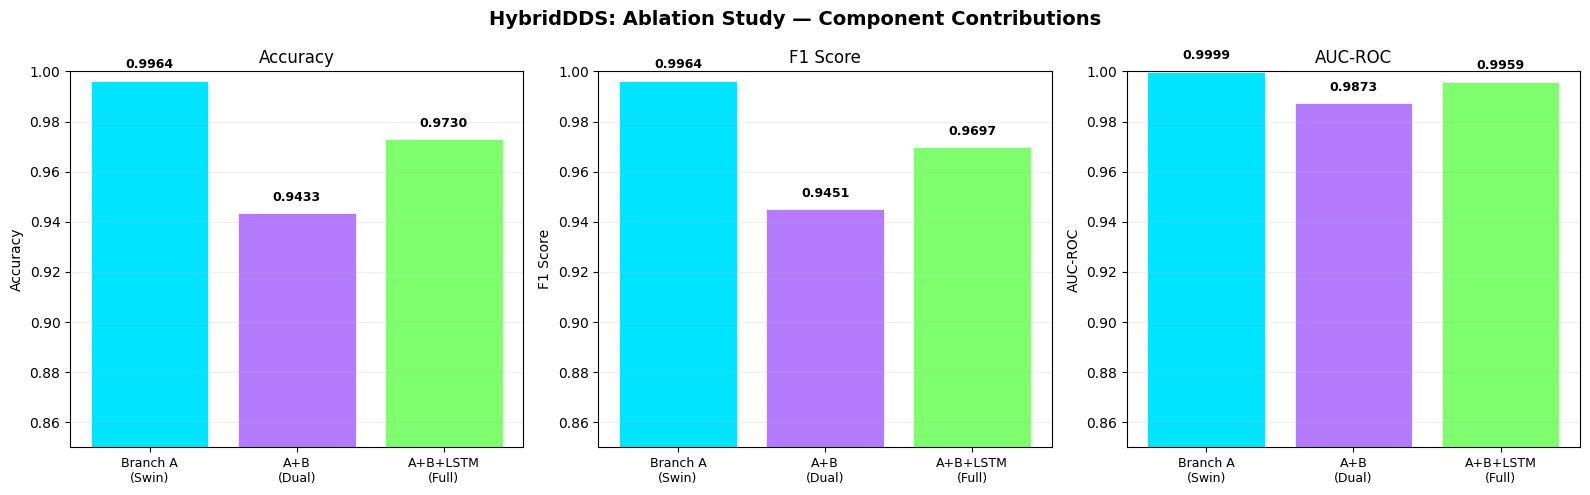


  CROSS-DATASET EVALUATION SUMMARY

Dataset                     Train Size            Type      Used In
──────────────────────────────────────────────────────────────────────
Drowsiness Det                  48,000       Eye crops      Phase 1
NTHU-DDD                        18,000       Full face      Phase 2
YawDD                          ~19,170    Video frames    Phase 3+4

✅ All results saved to /kaggle/working/output/
   → ablation_study.png
   → results_summary.json

🎉 HybridDDS BUILD COMPLETE!


In [37]:
# ============================================================
# CELL 26: Phase 5 — Full Evaluation + Ablation + Paper Figures
# ============================================================

# Load best full model
best_full = torch.load(
    os.path.join(CFG.CHECKPOINT_DIR, 'best_hybrid_full.pth'),
    weights_only=False
)
hybrid_full.load_state_dict(best_full['model_state_dict'])
print(f"✅ Loaded best HybridDDS Full (epoch {best_full['epoch']}, AUC: {best_full['val_auc']:.4f})")

# ─── Test Set Evaluation ───
test_loss, test_acc, test_f1, test_auc = validate_temporal(
    hybrid_full, temporal_test_loader, criterion_full, CFG.DEVICE
)

print(f"\n{'=' * 60}")
print(f"  FINAL TEST RESULTS — HybridDDS Full (Temporal)")
print(f"{'=' * 60}")
print(f"  Accuracy  : {test_acc:.4f}")
print(f"  F1 Score  : {test_f1:.4f}")
print(f"  AUC-ROC   : {test_auc:.4f}")

# ─── Ablation Study ───
print(f"\n{'=' * 60}")
print(f"  ABLATION STUDY — Component Contributions")
print(f"{'=' * 60}")

# Phase 1 results (Branch A only — Swin on eye state)
p1 = torch.load(os.path.join(CFG.CHECKPOINT_DIR, 'best_swin_phase1.pth'), weights_only=False)

# Phase 2 results (Branch A + B — Dual branch, no LSTM)
p2 = torch.load(os.path.join(CFG.CHECKPOINT_DIR, 'best_hybrid_v1.pth'), weights_only=False)

ablation_results = {
    'Branch A Only (Swin)': {
        'dataset': 'Drowsiness Det (48K)',
        'acc': max(p1['history']['val_acc']),
        'f1': p1['val_f1'],
        'auc': p1['val_auc'],
    },
    'Branch A+B (Dual, no LSTM)': {
        'dataset': 'NTHU-DDD (18K)',
        'acc': p2['val_acc'],
        'f1': p2['val_f1'],
        'auc': p2['val_auc'],
    },
    'Full HybridDDS (A+B+LSTM)': {
        'dataset': 'NTHU+YawDD Combined',
        'acc': test_acc,
        'f1': test_f1,
        'auc': test_auc,
    },
}

print(f"\n{'Model':<35s} {'Dataset':<25s} {'Acc':>8s} {'F1':>8s} {'AUC':>8s}")
print(f"{'─'*90}")
for model_name, metrics in ablation_results.items():
    print(f"{model_name:<35s} {metrics['dataset']:<25s} "
          f"{metrics['acc']:>8.4f} {metrics['f1']:>8.4f} {metrics['auc']:>8.4f}")

# ─── Paper-Ready Comparison Figure ───
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('HybridDDS: Ablation Study — Component Contributions', fontsize=14, fontweight='bold')

models = list(ablation_results.keys())
colors = ['#00e5ff', '#b57bff', '#7fff6e']

# Accuracy
accs = [ablation_results[m]['acc'] for m in models]
bars = axes[0].bar(range(len(models)), accs, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_xticks(range(len(models)))
axes[0].set_xticklabels(['Branch A\n(Swin)', 'A+B\n(Dual)', 'A+B+LSTM\n(Full)'], fontsize=9)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy')
axes[0].set_ylim([0.85, 1.0])
for bar, val in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
                 f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
axes[0].grid(True, alpha=0.2, axis='y')

# F1
f1s = [ablation_results[m]['f1'] for m in models]
bars = axes[1].bar(range(len(models)), f1s, color=colors, edgecolor='white', linewidth=0.5)
axes[1].set_xticks(range(len(models)))
axes[1].set_xticklabels(['Branch A\n(Swin)', 'A+B\n(Dual)', 'A+B+LSTM\n(Full)'], fontsize=9)
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 Score')
axes[1].set_ylim([0.85, 1.0])
for bar, val in zip(bars, f1s):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
axes[1].grid(True, alpha=0.2, axis='y')

# AUC
aucs = [ablation_results[m]['auc'] for m in models]
bars = axes[2].bar(range(len(models)), aucs, color=colors, edgecolor='white', linewidth=0.5)
axes[2].set_xticks(range(len(models)))
axes[2].set_xticklabels(['Branch A\n(Swin)', 'A+B\n(Dual)', 'A+B+LSTM\n(Full)'], fontsize=9)
axes[2].set_ylabel('AUC-ROC')
axes[2].set_title('AUC-ROC')
axes[2].set_ylim([0.85, 1.0])
for bar, val in zip(bars, aucs):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
axes[2].grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(CFG.OUTPUT_DIR, 'ablation_study.png'), dpi=200, bbox_inches='tight')
plt.show()

# ─── Cross-Dataset Summary Table ───
print(f"\n{'=' * 60}")
print(f"  CROSS-DATASET EVALUATION SUMMARY")
print(f"{'=' * 60}")
print(f"\n{'Dataset':<25s} {'Train Size':>12s} {'Type':>15s} {'Used In':>12s}")
print(f"{'─'*70}")
print(f"{'Drowsiness Det':<25s} {'48,000':>12s} {'Eye crops':>15s} {'Phase 1':>12s}")
print(f"{'NTHU-DDD':<25s} {'18,000':>12s} {'Full face':>15s} {'Phase 2':>12s}")
print(f"{'YawDD':<25s} {f'~{len(all_yawdd_records):,}':>12s} {'Video frames':>15s} {'Phase 3+4':>12s}")

# ─── Save final summary ───
summary = {
    'phase1': {'model': 'Swin Tiny', 'dataset': 'Drowsiness Detection', 
               'acc': accs[0], 'f1': f1s[0], 'auc': aucs[0]},
    'phase2': {'model': 'HybridDDS v1 (A+B)', 'dataset': 'NTHU-DDD',
               'acc': accs[1], 'f1': f1s[1], 'auc': aucs[1]},
    'phase4': {'model': 'HybridDDS Full (A+B+LSTM)', 'dataset': 'NTHU+YawDD',
               'acc': accs[2], 'f1': f1s[2], 'auc': aucs[2]},
}

import json
with open(os.path.join(CFG.OUTPUT_DIR, 'results_summary.json'), 'w') as f:
    json.dump(summary, f, indent=2)

print(f"\n✅ All results saved to {CFG.OUTPUT_DIR}/")
print(f"   → ablation_study.png")
print(f"   → results_summary.json")
print(f"\n🎉 HybridDDS BUILD COMPLETE!")

In [38]:
# ============================================================
# RUN THIS BEFORE STOPPING — Package all checkpoints for download
# ============================================================
import shutil

# Zip everything important
save_dir = '/kaggle/working'

shutil.make_archive(
    '/kaggle/working/HybridDDS_checkpoints',  # output filename
    'zip',                                       # format
    '/kaggle/working/checkpoints'                # source dir
)

shutil.make_archive(
    '/kaggle/working/HybridDDS_outputs',
    'zip',
    '/kaggle/working/output'
)

print("✅ Files packaged for download:")
import os
for f in os.listdir(save_dir):
    if f.endswith('.zip'):
        size = os.path.getsize(os.path.join(save_dir, f)) / 1e6
        print(f"   📦 {f} ({size:.1f} MB)")

print("\n→ Click on the file in the Output panel (right sidebar) to download")
print("→ Or go to: File → Download → Download Output")

✅ Files packaged for download:
   📦 HybridDDS_outputs.zip (1874.7 MB)
   📦 HybridDDS_checkpoints.zip (720.8 MB)

→ Click on the file in the Output panel (right sidebar) to download
→ Or go to: File → Download → Download Output
